# TADF Phase 2b — Deep-Dive Families P / X / L / M — Results Analysis

**Data provenance:** `data/results/phase2b/<model>/<run_label>/` — three-tier grid per the Phase 2b build decision (Phase 2a notebook Section 5; IT-055/IT-056): nano 2× clean, mini 2× clean, gpt-5.2 1× clean; temperature 0, seed 42; both paradigm implementations imported UNCHANGED from archetype F (frozen artifact state). Scoring: outcome-centric post-state predicates (`experiments/seed_p.py` etc.), deterministically verified by self-check plus adversarial simulations before any sweep.

**Families:** P (Plan Uncertainty — swept and analyzed below) · X (Crossed Gates) · L (Payload Scaling) · M (Moving Target) — sections prepared, filled as each family is swept. The loader is family-generic.

**Read discipline:** per-cell n is 5; two runs on nano/mini bound run-to-run noise (Phase 2a flip rate: 10.2%); read patterns, not point estimates. Ad-hoc smoke runs are excluded; where an instance was corrected and re-run, the loader keeps the **latest** run per (family, instance, model, run_label, paradigm) — the re-run discipline of IT-057.

**Per the IT-055 DSR note,** no routing direction was attached to any variant before the sweep; the routing derivations at the end of each family section are made from these results.

**Structure:** Setup → Family P (tables, figures, findings, routing derivation) → Families X / L / M (prepared) → Phase 2b synthesis. Every code cell is preceded by a short plain-English note describing what it does.

## Requirements

*What the next cell does:* it installs matplotlib into the current kernel (idempotent; needed for the charts). Run once, then restart the kernel and Run All.

In [117]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Setup — load the Phase 2b results

*What the next cell does:* it loads every `*_validation_*.json` under `data/results/phase2b/` into `ROWS`, skipping ad-hoc runs and deduplicating to the latest run per (family, instance, model, run_label, paradigm). It defines the model tiers, the house palette (blue = LLM workflow, purple = agent — identical to the Phase 2a notebook), and the helpers used by every table and chart.

In [118]:
import json, statistics
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
BASE = REPO / 'data' / 'results' / 'phase2b'

_raw: dict = {}
for fpath in sorted(BASE.glob('*/*/*_validation_*.json')):
    d = json.loads(fpath.read_text())
    if d.get('run_label') == 'adhoc':
        continue  # smoke runs are not evidence
    for r in d['runs']:
        key = (r.get('family', '?'), r['instance'], d['model'], d['run_label'], r['paradigm'])
        prev = _raw.get(key)
        if prev is None or d['timestamp'] > prev['_ts']:
            _raw[key] = {**r, 'model': d['model'], 'run_label': d['run_label'], '_ts': d['timestamp']}
ROWS = list(_raw.values())

MODELS = ['gpt-5.4-nano-2026-03-17', 'gpt-5.4-mini-2026-03-17', 'gpt-5.2-2025-12-11']
SHORT = {m: m.split('-2026')[0].split('-2025')[0] for m in MODELS}
CELLS = [(MODELS[0], 'run1'), (MODELS[0], 'run2'), (MODELS[1], 'run1'), (MODELS[1], 'run2'), (MODELS[2], 'run1')]

# House style (identical to the Phase 2a notebook)
C_WF = '#5b8db8'; C_AG = '#9b7fbf'
PCOL = {'workflow': C_WF, 'agent': C_AG}
MCOL = {MODELS[0]: '#b9cede', MODELS[1]: '#7da7c9', MODELS[2]: '#3f6e99'}
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

def _rate(rows):
    v = [r for r in rows if 'correct' in r]
    return 100 * sum(1 for r in v if r.get('correct')) / len(v) if v else 0

def _avg_tok(rows):
    t = [float(r['total_tokens']) for r in rows if r.get('total_tokens')]
    return statistics.mean(t) if t else 0

def fam_rows(fam, **kw):
    out = [r for r in ROWS if r.get('family') == fam]
    for k, v in kw.items():
        out = [r for r in out if r.get(k) == v]
    return out

print(f'{len(ROWS)} deduped grid rows | families: ' + ', '.join(sorted({r.get("family","?") for r in ROWS})))

680 deduped grid rows | families: L, M, P, X


## 1. Family P — Plan Uncertainty

Design (IT-056): four variants × 5 instances on the frozen CRM seed, each isolating exactly one plan-uncertainty axis. **a_count_read** — action count not stated but derivable from one read (control axis). **b_count_outcome** — count depends on each action's runtime outcome (close oldest-first, stop at the first back-end refusal; deterministic stop points). **c_source_unknown** — the needed fact lives in exactly one of mailbox / calendar / CRM. **d_derived_order** — send order must be derived from record data (control axis; verified through monotone outbox ids).

Two corrections, both logged (IT-056/IT-057) and applied before this analysis: subject matching accepts zero-padded record ids (post-smoke hardening; scoring the construct, not padding style), and the p-d-3 gold was corrected (opportunity 12 was missing from the anchor query; the affected cells were re-run and the loader keeps the latest runs).

*What the next cell does:* it prints the family-P scorecard — success per variant × paradigm for each grid cell plus the pooled score and average token cost — and lists the hard errors.

In [119]:
VARIANTS_P = ['a_count_read', 'b_count_outcome', 'c_source_unknown', 'd_derived_order']

hdr = ''.join(f'{SHORT[m][-4:]+" "+l[-1]:>9}' for m, l in CELLS)
print(f'{"variant":16} {"paradigm":9}' + hdr + f'{"pooled":>9} {"avg_tok":>8}')
for v in VARIANTS_P:
    for p in ('workflow', 'agent'):
        line = f'{v:16} {p:9}'
        ok = tot = 0
        for m, l in CELLS:
            sub = fam_rows('P', variant=v, paradigm=p, model=m, run_label=l)
            k = sum(1 for r in sub if r.get('correct')); ok += k; tot += len(sub)
            line += f'{f"{k}/{len(sub)}":>9}'
        line += f'{f"{ok}/{tot}":>9} {_avg_tok(fam_rows("P", variant=v, paradigm=p)):>8.0f}'
        print(line)

errs = [r for r in fam_rows('P') if r.get('error')]
print(f'\nHARD ERRORS: {len(errs)}')
for r in errs:
    print(f'  {r["instance"]:7} {SHORT[r["model"]]:12} {r["run_label"]:5} {r["paradigm"]:9} :: {str(r["error"])[:70]}')

variant          paradigm    nano 1   nano 2   mini 1   mini 2   -5.2 1   pooled  avg_tok
a_count_read     workflow       5/5      5/5      5/5      5/5      5/5    25/25     3346
a_count_read     agent          5/5      5/5      5/5      5/5      5/5    25/25     9393
b_count_outcome  workflow       0/5      0/5      0/5      0/5      0/5     0/25     4084
b_count_outcome  agent          4/5      3/5      1/5      2/5      5/5    15/25    19099
c_source_unknown workflow       1/5      2/5      3/5      3/5      3/5    12/25     4534
c_source_unknown agent          5/5      5/5      5/5      5/5      4/5    24/25    13335
d_derived_order  workflow       1/5      2/5      3/5      3/5      5/5    14/25     4177
d_derived_order  agent          2/5      3/5      4/5      3/5      5/5    17/25    29723

HARD ERRORS: 2
  p-b-2   gpt-5.2      run1  workflow  :: 9 validation errors for ReadPlan
reads.0.args.filters.str
  Input shou
  p-c-3   gpt-5.4-nano run2  workflow  :: 9 validation errors

*What the next cell does:* it draws the family-P summary — left panel: pooled success per variant, workflow vs agent bars; right panel: average total tokens per variant (log scale). House palette; the per-cell scores behind the bars are in the table above.

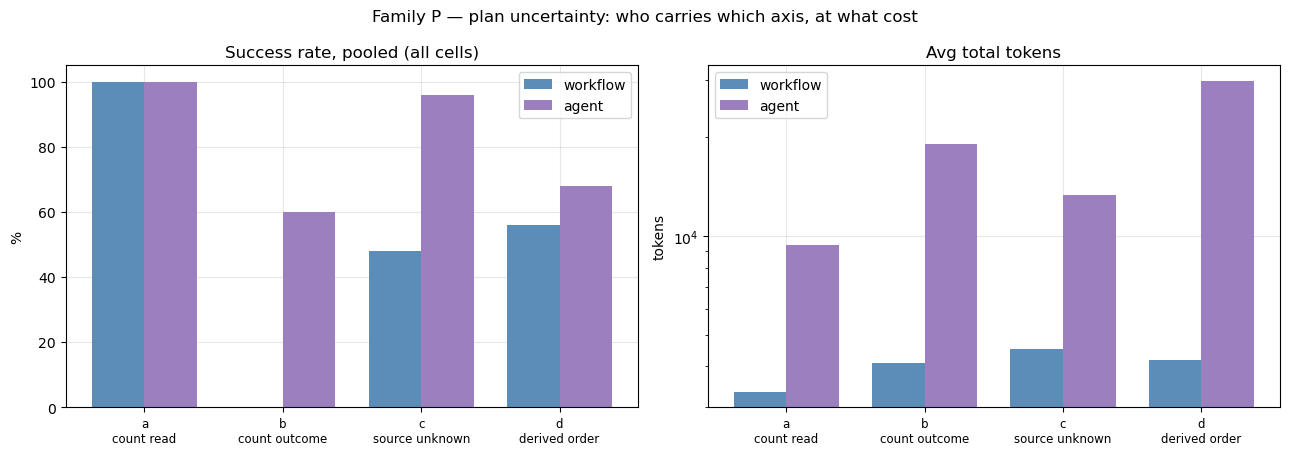

In [120]:
xs = np.arange(len(VARIANTS_P)); w = 0.38
labels = [v.split('_', 1)[0] + '\n' + v.split('_', 1)[1].replace('_', ' ') for v in VARIANTS_P]
f, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for i, p in enumerate(('workflow', 'agent')):
    off = (i - 0.5) * w
    ax[0].bar(xs + off, [_rate(fam_rows('P', variant=v, paradigm=p)) for v in VARIANTS_P], w, label=p, color=PCOL[p])
    ax[1].bar(xs + off, [_avg_tok(fam_rows('P', variant=v, paradigm=p)) for v in VARIANTS_P], w, label=p, color=PCOL[p])
ax[0].set_title('Success rate, pooled (all cells)'); ax[0].set_ylabel('%'); ax[0].set_ylim(0, 105)
ax[1].set_title('Avg total tokens'); ax[1].set_ylabel('tokens'); ax[1].set_yscale('log')
for a in ax:
    a.set_xticks(xs); a.set_xticklabels(labels, fontsize=8.5); a.legend()
f.suptitle('Family P — plan uncertainty: who carries which axis, at what cost', fontsize=12)
plt.tight_layout(); plt.show()

*What the next cell does:* it draws the capability gradient — one panel per variant, success rate across the three tiers (nano and mini averaged over their two runs), one line per paradigm. This separates structural effects (flat lines) from capability-bound ones (rising lines).

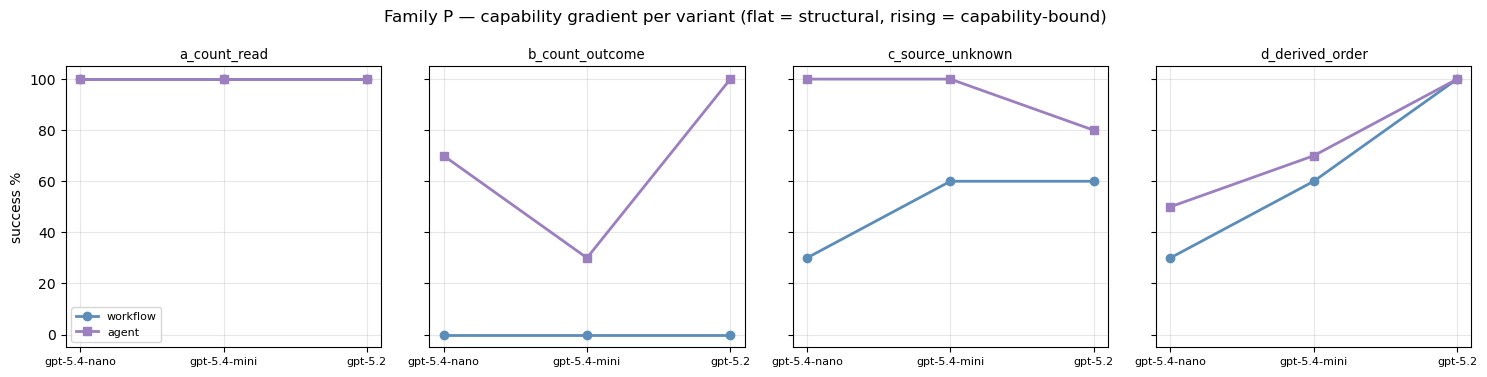

In [121]:
TIERS = [(MODELS[0], ('run1', 'run2')), (MODELS[1], ('run1', 'run2')), (MODELS[2], ('run1',))]
tx = np.arange(3); tlabels = [SHORT[m] for m, _ in TIERS]
f, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for a, v in zip(axes, VARIANTS_P):
    for p, marker in (('workflow', 'o'), ('agent', 's')):
        ys = []
        for m, ls in TIERS:
            sub = [r for r in fam_rows('P', variant=v, paradigm=p, model=m) if r['run_label'] in ls]
            ys.append(_rate(sub))
        a.plot(tx, ys, '-', marker=marker, color=PCOL[p], linewidth=2, label=p)
    a.set_title(v, fontsize=9.5); a.set_xticks(tx); a.set_xticklabels(tlabels, fontsize=8)
    a.set_ylim(-5, 105)
axes[0].set_ylabel('success %'); axes[0].legend(fontsize=8)
f.suptitle('Family P — capability gradient per variant (flat = structural, rising = capability-bound)', fontsize=12)
plt.tight_layout(); plt.show()

### Findings P

**P-a (count data-bounded — control axis).** 25/25 for BOTH paradigms in every cell, workflow at 0.36× the tokens (3.3k vs 9.4k). An action count that is unknown at plan time but derivable from one read is **not** a planning gap: the two-stage form reads, sees the matching rows, and expands one action per row. Confirms and isolates the f-med-4 reading.

**P-b (count outcome-dependent).** Workflow **0/25 — a structural zero across all three tiers**, exactly the F-runtime signature: the deterministic executor cannot stop at a refusal it has not seen at plan time; traces show close-through past the refusal point. Agent 15/25 with a non-monotone tier pattern (nano 7/10, mini 3/10, gpt-5.2 5/5). *Open:* the mini failures carry correct-sounding self-reports ("closed until refused, then notified ops") — self-reports are known-unreliable (IT-052) and no trace evidence overturns the post-state scoring, but the mini dip should be re-read once family X provides more repeat-until cells.

**P-c (source unknown).** Agent 24/25 vs workflow 12/25. The workflow's read fan-out partially compensates with capability (nano 3/10 → mini 6/10 → 5.2 3/5) but never approaches the agent, which searches, misses, and re-searches the next source. The one agent miss is a 5.2 run of p-c-1. Cost: agent 2.9× (13.3k vs 4.5k).

**P-d (derived ordering — control axis).** Near-parity overall (W 14/25 vs A 17/25) with a clean capability gradient for both — and **5/5 for both at the reference tier**. Ordering that must be derived from read data is plan-time decidable *given sufficient capability*; below the reference tier both paradigms drop, so this is a capability floor, not a paradigm gap. Note the agent's token bill here: 29.7k vs 4.2k (7.1×) — the notification loop re-enters the growing mailbox payloads every iteration.

**Corrections trail (audit):** p-d-3 was scored 0/10 for both paradigms before the gold correction (the models were right, the anchor query had missed opportunity 12) — the two-sided zero was the tell; instance-level both-paradigm zeros should always trigger a gold review before a saturation reading. The padded-subject hardening (post-smoke) is the same lesson at the scoring layer.

**Hard errors:** two workflow structured-output validation crashes (ReadPlan on 5.2/p-b-2, ActionPlan on nano/p-c-3) — the known schema-ceiling fragility, now also observed on the reference tier's read stage.

### Routing derivation — updates to TADF table rows 3.3 / 3.4

Applied to the framework (Phase 2a notebook, Section 4.3) from these results — decision rule fixed in advance: a variant routes when the pooled workflow–agent gap exceeds the two-run noise band across tiers; control axes resolve to "no gate".

- **Row 3.3 (call count unknown) splits into two conditions:** count *data-bounded* (derivable from a read) → **no gate — LLM workflow carries it at parity and 0.36× cost** (P-a 25/25 both). Count *outcome-dependent* (repeat-until) → **AGENT, hard break** (P-b: W 0/25 tier-invariant vs A 15/25) — an extension of the G1 runtime-feedback mechanism to iteration counts.
- **Row 3.4 (which tool/source unknown) → AGENT, hard break** (P-c: 24/25 vs 12/25; the workflow's fan-out narrows the gap with capability but never closes it). Capability note: re-check at reference tier where the observed gap is small (4/5 vs 3/5 on n=5).
- **Row 3.5 (default) gains an evidence note:** derived ordering and data-bounded counts stay plan-time decidable (P-a; P-d both 5/5 at the reference tier, capability-bound below).
- **Unchanged:** no evidence here touches rows 1.x, 2.1/2.2, 4.x-7.x.

### Ergebnisse in einfacher Sprache (plain-language summary, Family P)

Familie P hat getestet, **woran genau es liegt, wenn eine Aufgabe "nicht planbar" ist** — und ob man deshalb wirklich einen Agent braucht. Vier Fälle, vier Antworten:

**Fall 1 — Man weiß nicht, *wie viele* Aktionen es werden, aber die Daten verraten es (P-a).** Beispiel: "Setze alle offenen Medium-Cases von Account 15 auf High" — ob das 2 oder 6 Cases sind, steht nirgends im Auftrag. **Ergebnis: beide Paradigmen 25/25 (100%), der Workflow zu 0,36× der Kosten (3.346 vs. 9.393 Tokens).** Warum: Der Workflow liest einmal, sieht die Treffer und plant pro Treffer eine Aktion. Unbekannte Anzahl allein ist also *kein* Grund für einen Agent.

**Fall 2 — Wie viele Aktionen es werden, entscheidet sich erst *während* der Ausführung (P-b).** Beispiel: "Schließe die Cases der Reihe nach, bis das Back-End einen ablehnt — dann stopp." **Ergebnis: Workflow 0/25 — null Erfolge, bei jedem Modell.** Er legt den Plan vorher fest, und der Ausführer läuft stur durch: Er schließt am Ablehnungspunkt vorbei weiter. Der Agent sieht die Ablehnung und stoppt (15/25; auf dem stärksten Modell 5/5). → **Harter Agent-Fall.**

**Fall 3 — Man weiß nicht, *wo* die Information liegt (P-c).** "War das eine Mail, ein Termin oder ein Case? Keine Ahnung." **Ergebnis: Agent 24/25, Workflow 12/25.** Der Agent sucht in Quelle 1, findet nichts, probiert Quelle 2. Der Workflow muss alle Suchen vorher raten — mit stärkerem Modell rät er besser (nano 3/10 → gpt-5.2 3/5), erreicht den Agent aber nie. → **Harter Agent-Fall.**

**Fall 4 — Die *Reihenfolge* muss aus den Daten abgeleitet werden (P-d).** "Benachrichtige die Owner, ältester Case zuerst." **Ergebnis: Mit dem starken Modell beide 5/5** (darunter fallen beide ab: Workflow 14/25, Agent 17/25 gesamt) — das ist kein Paradigma-Problem, sondern eine Frage der Modellstärke. Und der Workflow ist hier 7× billiger (4.177 vs. 29.723 Tokens).

**Die eine Regel, die daraus folgt:** Entscheidend ist nicht, *wie gut* eine Aufgabe planbar ist, sondern ob während der Ausführung Information **entsteht**, die der Plan gebraucht hätte. Alles, was man durch einmaliges Nachschlagen *vor* dem Handeln klären kann (Anzahl, Reihenfolge), trägt der Workflow — bei gleicher Qualität deutlich billiger. Was sich erst *durch* das Handeln zeigt (Aktions-Ergebnisse, Fundort), braucht den Agent.

**Für das Framework heißt das:** Die zwei offenen (amber) Fragen der Entscheidungstabelle sind beantwortet — Zeile 3.3 splittet in "aus Daten ablesbar → Workflow" und "ergebnisabhängig → rot, Agent"; Zeile 3.4 (Quelle unbekannt) → rot, Agent. Ein Architekt fragt jetzt konkret: *"Weiß ich erst nach einer Aktion, wie es weitergeht?"* — wenn ja, Agent; kann er alles vorher nachschlagen, Workflow. Nebenbefund für Kapitel 4.5: Die a-priori-Dimension "Step Predictability" hätte Fall 1 und Fall 4 falsch geroutet — der direkte Beleg für die Dimension-Revision (Phase-2a-Notebook, Section 5).


## 2. Family X — Crossed Gates

Design (IT-058): three variants × 5 instances, each crossing exactly **two** routing mechanisms, to test the cascade's first-match order and the v1-vs-v2 question of Section 4.1 (Phase 2a notebook). **x1_rule_on_outcome (D4×D1)** — a codifiable three-rule matrix whose *input* is the runtime outcome of `attempt_close_case`. **x2_chain_heterogeneous (D2×D3)** — a two-hop chain (contact → account → its open opportunities) feeding heterogeneous per-record updates. **x3_rules_heterogeneous (D4×D3)** — a fully plan-time-decidable triage matrix that forces a heterogeneous plan object; v1 (G2 before G4) routes it to the workflow, v2 (D3 before D4) to the agent — **the discriminating cell**. Anchor discipline: all target sets computed from the seed with import-time assertions; interpretation note: rules live in the shared runbook and are applied by the planner LLM (canonical F forms; archetype D's deterministic engine is a build response, not the baseline).

*What the next cell does:* it prints the family-X scorecard — success per variant × paradigm for each grid cell, pooled score, and average token cost — and lists the hard errors.


In [122]:
VARIANTS_X = ['x1_rule_on_outcome', 'x2_chain_heterogeneous', 'x3_rules_heterogeneous']

hdr = ''.join(f'{SHORT[m][-4:]+" "+l[-1]:>9}' for m, l in CELLS)
print(f'{"variant":22} {"paradigm":9}' + hdr + f'{"pooled":>9} {"avg_tok":>8}')
for v in VARIANTS_X:
    for p in ('workflow', 'agent'):
        line = f'{v:22} {p:9}'
        ok = tot = 0
        for m, l in CELLS:
            sub = fam_rows('X', variant=v, paradigm=p, model=m, run_label=l)
            k = sum(1 for r in sub if r.get('correct')); ok += k; tot += len(sub)
            line += f'{f"{k}/{len(sub)}":>9}'
        line += f'{f"{ok}/{tot}":>9} {_avg_tok(fam_rows("X", variant=v, paradigm=p)):>8.0f}'
        print(line)

ref = MODELS[2]
print('\nreference tier (gpt-5.2) only:')
for v in VARIANTS_X:
    for p in ('workflow', 'agent'):
        sub = fam_rows('X', variant=v, paradigm=p, model=ref)
        print(f'  {v:22} {p:9} {sum(1 for r in sub if r.get("correct"))}/{len(sub)}  avg_tok {_avg_tok(sub):6.0f}')

errs = [r for r in fam_rows('X') if r.get('error')]
print(f'\nHARD ERRORS: {len(errs)}')
for r in errs:
    print(f'  {r["instance"]:6} {SHORT[r["model"]]:12} {r["run_label"]:5} {r["paradigm"]:9} :: {str(r["error"])[:70]}')

variant                paradigm    nano 1   nano 2   mini 1   mini 2   -5.2 1   pooled  avg_tok
x1_rule_on_outcome     workflow       0/5      0/5      0/5      0/5      0/5     0/25     4074
x1_rule_on_outcome     agent          5/5      4/5      5/5      5/5      5/5    24/25    14356
x2_chain_heterogeneous workflow       0/5      0/5      0/5      0/5      0/5     0/25     3664
x2_chain_heterogeneous agent          5/5      5/5      5/5      4/5      5/5    24/25    13790
x3_rules_heterogeneous workflow       0/5      1/5      2/5      2/5      5/5    10/25     3768
x3_rules_heterogeneous agent          2/5      2/5      5/5      5/5      5/5    19/25    11122

reference tier (gpt-5.2) only:
  x1_rule_on_outcome     workflow  0/5  avg_tok   4108
  x1_rule_on_outcome     agent     5/5  avg_tok  13811
  x2_chain_heterogeneous workflow  0/5  avg_tok   3382
  x2_chain_heterogeneous agent     5/5  avg_tok  12426
  x3_rules_heterogeneous workflow  5/5  avg_tok   4001
  x3_rules_heterogene

*What the next cell does:* it draws the family-X summary (pooled success and log-scale token bars per variant) and the capability gradient per variant — the gradient is where the v1-vs-v2 answer lives: a flat workflow zero means the crossing is structural, a rising workflow line means it is capability-bound.

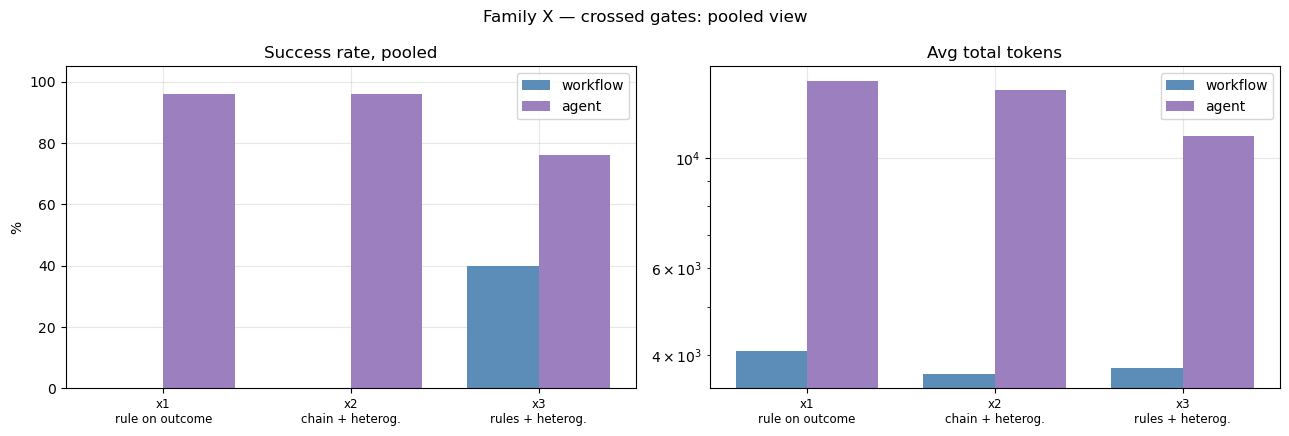

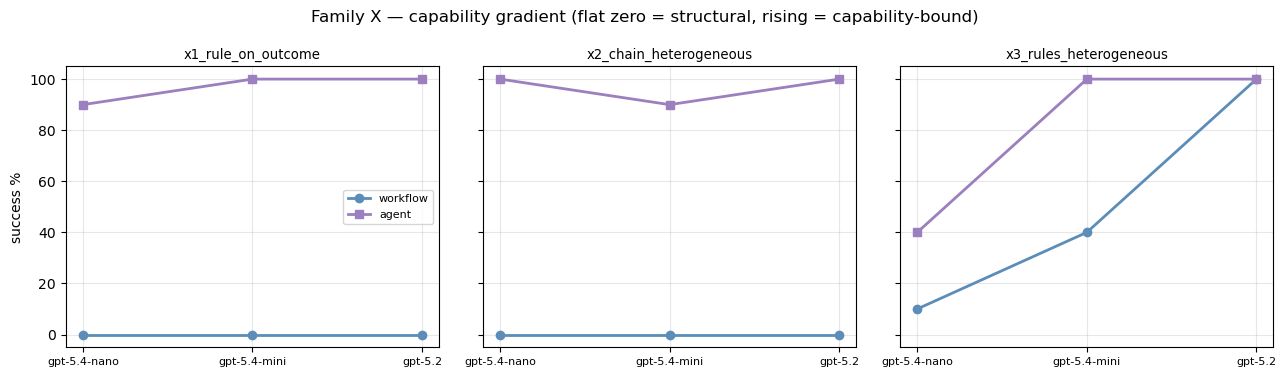

In [123]:
xs = np.arange(len(VARIANTS_X)); w = 0.38
labels = ['x1\nrule on outcome', 'x2\nchain + heterog.', 'x3\nrules + heterog.']
f, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for i, p in enumerate(('workflow', 'agent')):
    off = (i - 0.5) * w
    ax[0].bar(xs + off, [_rate(fam_rows('X', variant=v, paradigm=p)) for v in VARIANTS_X], w, label=p, color=PCOL[p])
    ax[1].bar(xs + off, [_avg_tok(fam_rows('X', variant=v, paradigm=p)) for v in VARIANTS_X], w, label=p, color=PCOL[p])
ax[0].set_title('Success rate, pooled'); ax[0].set_ylabel('%'); ax[0].set_ylim(0, 105)
ax[1].set_title('Avg total tokens'); ax[1].set_yscale('log')
for a in ax:
    a.set_xticks(xs); a.set_xticklabels(labels, fontsize=8.5); a.legend()
f.suptitle('Family X — crossed gates: pooled view', fontsize=12)
plt.tight_layout(); plt.show()

f, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for a, v in zip(axes, VARIANTS_X):
    for p, marker in (('workflow', 'o'), ('agent', 's')):
        ys = []
        for m, ls in TIERS:
            sub = [r for r in fam_rows('X', variant=v, paradigm=p, model=m) if r['run_label'] in ls]
            ys.append(_rate(sub))
        a.plot(tx, ys, '-', marker=marker, color=PCOL[p], linewidth=2, label=p)
    a.set_title(v, fontsize=9.5); a.set_xticks(tx); a.set_xticklabels(tlabels, fontsize=8)
    a.set_ylim(-5, 105)
axes[0].set_ylabel('success %'); axes[0].legend(fontsize=8)
f.suptitle('Family X — capability gradient (flat zero = structural, rising = capability-bound)', fontsize=12)
plt.tight_layout(); plt.show()

### Findings X

**x1 (rule matrix on runtime outcomes, D4×D1).** Workflow **0/25 — structurally zero at every tier** — vs agent 24/25. Codifiability does *not* rescue the two-stage form when the rules' input is an action outcome: the planner cannot know which rule branch fires, and the executor cannot switch branches. The cascade's order **G1 before G2 is empirically confirmed**. Side finding: five of the six hard errors are mini `ReadPlan` validation crashes on x1 instructions — the schema ceiling now also visible in the *read* stage.

**x2 (chain into heterogeneous updates, D2×D3).** Workflow **0/25** vs agent 24/25 — the two agent-pointing mechanisms compound without saturating: the agent carries the cell at every tier (only 2 single misses). Notably, the theoretically available workflow escape (unfiltered full-table read to collapse the chain) did not materialize — the heterogeneous update stage breaks the plan even where the chain could have been brute-forced.

**x3 (plan-time rule matrix forcing a heterogeneous plan, D4×D3) — the discriminating cell.** Workflow 10/25 with a steep capability gradient (nano 1/10 → mini 4/10 → **gpt-5.2 5/5**); agent 19/25 (nano 4/10 → mini 10/10 → 5/5). **At the reference tier both paradigms are perfect and the workflow is ~3× cheaper; below it the agent wins.** Neither framework form gets this cell universally right: v1's G2-first routing is correct *at the reference tier*, v2's D3-first routing is correct *below* it. Read with f-med-3 (Phase 2a: unbounded per-item heterogeneity, W 2/5 even pooled), the schema ceiling binds on the *degree* of heterogeneity: bounded, rule-generated variety (three argument shapes) is workflow-feasible at sufficient capability; unbounded per-item variety is not.

**Cost.** Agent premium: x1 3.5×, x2 3.8×, x3 2.9× (at the reference tier, x3: parity in success, workflow ~3× cheaper — the premium buys nothing there).

### Routing derivation — the v1-vs-v2 decision (agenda item 9, resolved)

- **Cascade order G1 ⊐ G2 confirmed** (x1: W 0/25 tier-invariant): if the decision logic's *input* is a runtime outcome, row 2.1 fires and codifiability is irrelevant. The table's evaluation order already encodes this — an evidence note is added to row 3.2.
- **G3/G4 compound without saturation** (x2): both point to the agent; no third outcome needed.
- **The strict hierarchy (v2) is refuted as a universal:** its subordination D3 ⊐ D4 holds only *below* the reference tier; at the reference tier the v1 routing (G2 → workflow) is correct and 3× cheaper. Gate order is therefore **partially capability-dependent** — the hierarchical tree of Section 4.1 (Phase 2a notebook) stays a labelled hypothesis in its static form; the citable framework remains the v1 cascade, with the Stage-3 capability check carrying the x3 condition (bounded rule-generated heterogeneity → workflow from the reference tier, agent below).
- **Row 3.1 refinement:** the D3 hard break is confirmed for *unbounded per-item* heterogeneity (f-med-3); *bounded, rule-generated* variety is capability-conditional (X-3) — evidence note added to the table.

### Ergebnisse in einfacher Sprache (plain-language summary, Family X)

Familie X hat getestet, was passiert, wenn **zwei Routing-Regeln gleichzeitig zutreffen** — und welche dann gewinnt:

**Fall 1 — Die Regeln sind sauber aufschreibbar, aber ihr Input entsteht erst zur Laufzeit (x1).** "Schließe zwei Cases; was danach zu tun ist, hängt von der Antwort des Systems ab (Erfolg / Ablehnung / schon geschlossen)." **Ergebnis: Workflow 0/25 bei jedem Modell, Agent 24/25.** Schöne Regeln nützen nichts, wenn man erst nach der Aktion weiß, welche Regel gilt. → Die Reihenfolge im Framework stimmt: Erst nach Laufzeit-Abhängigkeit fragen, dann nach Regeln.

**Fall 2 — Suchkette plus unterschiedliche Änderungen pro Datensatz (x2).** "Finde den Account des Kontakts, dann passe jede seiner Opportunities nach Schwellwerten an." **Ergebnis: Workflow 0/25, Agent 24/25.** Zwei Agent-Gründe zusammen bleiben ein Agent-Fall — es entsteht kein unlösbarer Fall (keine Sättigung).

**Fall 3 — Alles vorher wissbar, aber jeder Datensatz braucht eine andere Aktion (x3, die Schiedsrichter-Zelle).** "Triage-Matrix: High → umhängen, Medium → hochstufen, Low → beides." **Ergebnis: Mit dem starken Modell beide perfekt (5/5), Workflow dabei 3× billiger — mit schwächeren Modellen gewinnt der Agent (mini: 10/10 vs. 4/10).** Das heißt: Ob hier Workflow oder Agent richtig ist, entscheidet die Modellstärke, nicht die Task allein.

**Was das für dein Framework bedeutet:** Die Kaskade (erst Laufzeit-Abhängigkeit, dann Regeln, dann Schema) **bleibt die richtige Form** — x1 bestätigt ihre Reihenfolge hart. Der strenge Baum (v2) ist damit widerlegt: Seine feste Unterordnung "Schema vor Regeln" gilt nur unterhalb des Referenz-Modells. Die Modellstärke-Prüfung (Stage 3) ist also kein Anhängsel, sondern trägt eine echte Routing-Entscheidung — genau die x3-Bedingung. Und eine Verfeinerung: "Jeder Datensatz anders" bricht den Workflow nur bei *unbegrenzter* Vielfalt (jedes Item eigene Werte); *regelerzeugte* Vielfalt (drei Aktionsformen) schafft der Workflow mit starkem Modell — billiger.

## 3. Family L — Payload Scaling

Design (IT-060): three gate-free task shapes × three payload levels (×1/×5/×20) × two instances, per-instance deterministic payload overlay on top of the untouched shared seed (identical pre-state for both paradigms; instruction templates identical across levels within a shape). **scan_scaling** — DB argmax over 8/40/160 cases, one action. **action_scaling** — homogeneous bulk update, 2/10/40 matching cases. **mail_scaling** — mailbox argmax over 10/50/200 Gmail-shaped payloads. Aggregation targets so the payload cannot be bypassed by filters. Resolves framework row 1.2 ([c₁], [b₁], [a₁], [a₂]).

*What the next cell does:* it prints the family-L scorecard — success per shape × level × paradigm for each grid cell, pooled, with average total/input tokens and latency — the raw material for the row-1.2 numbers.


In [124]:
SHAPES_L = ['scan_scaling', 'action_scaling', 'mail_scaling']
LEVELS_L = [1, 5, 20]

hdr = ''.join(f'{SHORT[m][-4:]+" "+l[-1]:>8}' for m, l in CELLS)
print(f'{"shape":15} {"lvl":>3} {"paradigm":9}' + hdr + f'{"pooled":>8} {"avg_tok":>8} {"in_tok":>8} {"lat_s":>6}')
for v in SHAPES_L:
    for lvl in LEVELS_L:
        for p in ('workflow', 'agent'):
            sub_all = fam_rows('L', variant=v, paradigm=p)
            sub_all = [r for r in sub_all if r.get('level') == lvl]
            line = f'{v:15} {lvl:>3} {p:9}'
            ok = tot = 0
            for m, l in CELLS:
                sub = [r for r in sub_all if (r['model'], r['run_label']) == (m, l)]
                k = sum(1 for r in sub if r.get('correct')); ok += k; tot += len(sub)
                line += f'{f"{k}/{len(sub)}":>8}'
            toks = [float(r['total_tokens']) for r in sub_all if r.get('total_tokens')]
            itoks = [float(r['input_tokens']) for r in sub_all if r.get('input_tokens')]
            lats = [float(r['latency_s']) for r in sub_all if r.get('latency_s')]
            line += (f'{f"{ok}/{tot}":>8} {statistics.mean(toks) if toks else 0:>8.0f} '
                     f'{statistics.mean(itoks) if itoks else 0:>8.0f} {statistics.mean(lats) if lats else 0:>6.1f}')
            print(line)

errs = [r for r in fam_rows('L') if r.get('error')]
print(f'\nHARD ERRORS: {len(errs)}')

shape           lvl paradigm   nano 1  nano 2  mini 1  mini 2  -5.2 1  pooled  avg_tok   in_tok  lat_s
scan_scaling      1 workflow      2/2     2/2     2/2     2/2     2/2   10/10     3259     3045    4.3
scan_scaling      1 agent         2/2     2/2     2/2     2/2     2/2   10/10     9366     9270    4.1
scan_scaling      5 workflow      2/2     2/2     2/2     2/2     2/2   10/10     4153     3925    3.9
scan_scaling      5 agent         2/2     2/2     2/2     2/2     2/2   10/10    12737    12640    4.9
scan_scaling     20 workflow      2/2     1/2     2/2     2/2     2/2    9/10     7360     7131    3.9
scan_scaling     20 agent         2/2     2/2     2/2     2/2     2/2   10/10    27281    27186    4.3
action_scaling    1 workflow      2/2     2/2     2/2     2/2     2/2   10/10     3173     2944    3.9
action_scaling    1 agent         2/2     2/2     2/2     2/2     2/2   10/10     8822     8681    4.2
action_scaling    5 workflow      2/2     2/2     2/2     2/2     2/2   1

*What the next cell does:* it draws the scaling curves — per shape, success (top row) and average input tokens (bottom row, log) across the payload levels, one line per paradigm. Flat success lines with diverging cost lines are the row-1.2 answer.

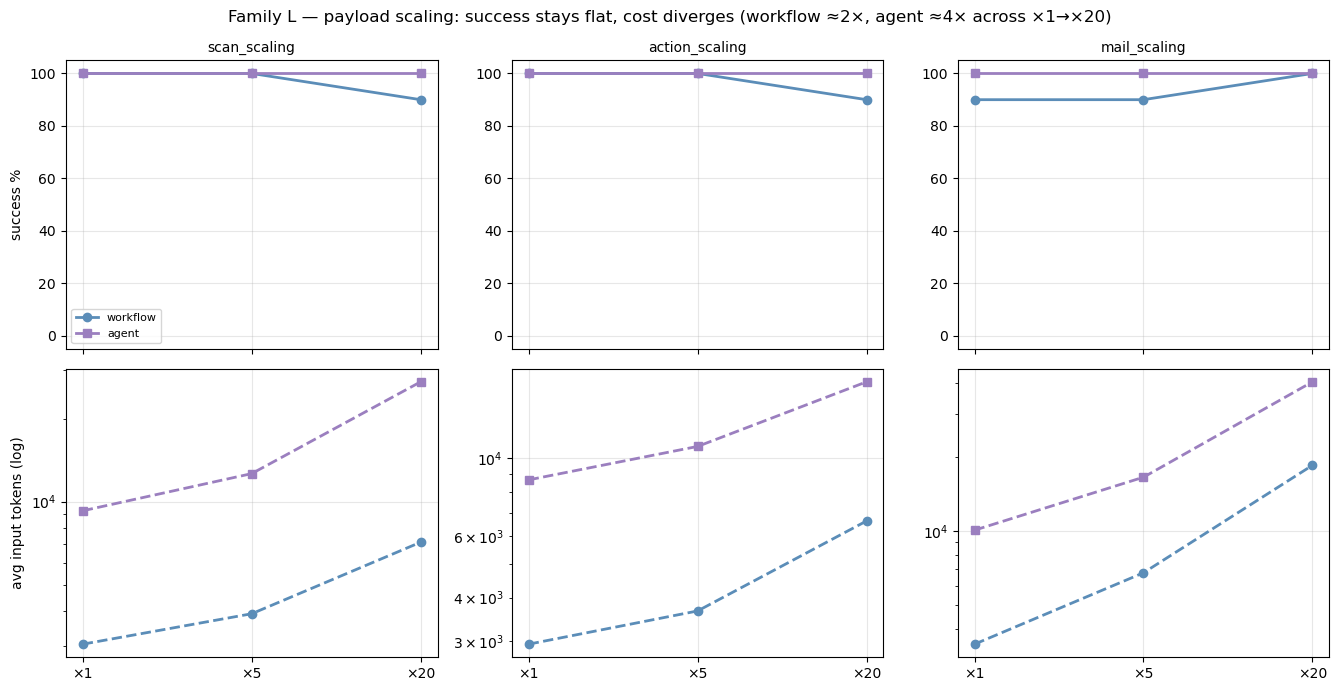

In [125]:
f, axes = plt.subplots(2, 3, figsize=(13.5, 7), sharex=True)
lx = np.arange(3)
for j, v in enumerate(SHAPES_L):
    for p, marker in (('workflow', 'o'), ('agent', 's')):
        ys_s, ys_t = [], []
        for lvl in LEVELS_L:
            sub = [r for r in fam_rows('L', variant=v, paradigm=p) if r.get('level') == lvl]
            ys_s.append(_rate(sub))
            it = [float(r['input_tokens']) for r in sub if r.get('input_tokens')]
            ys_t.append(statistics.mean(it) if it else 0)
        axes[0, j].plot(lx, ys_s, '-', marker=marker, color=PCOL[p], linewidth=2, label=p)
        axes[1, j].plot(lx, ys_t, '--', marker=marker, color=PCOL[p], linewidth=2, label=p)
    axes[0, j].set_title(v, fontsize=10); axes[0, j].set_ylim(-5, 105)
    axes[1, j].set_yscale('log'); axes[1, j].set_xticks(lx); axes[1, j].set_xticklabels(['×1', '×5', '×20'])
axes[0, 0].set_ylabel('success %'); axes[1, 0].set_ylabel('avg input tokens (log)')
axes[0, 0].legend(fontsize=8)
f.suptitle('Family L — payload scaling: success stays flat, cost diverges (workflow ≈2×, agent ≈4× across ×1→×20)', fontsize=12)
plt.tight_layout(); plt.show()

### Findings L

**Volume does not break either paradigm in the tested range — it breaks the bill.** In the DB shapes, success is level-invariant: scan 29/30 workflow vs 30/30 agent, action 29/30 vs 30/30 across ×1→×20 (160 records; zero hard errors in 180 family runs). What scales is cost: agent input tokens grow ≈2.9× in scan (9.3k → 27.2k) and ≈4× in mail (10.1k → 40.2k), while the workflow grows ≈2.3× (3.0k → 7.1k) — the payload re-enters the agent's context every loop turn but passes the workflow's context once. At ×20 the agent pays 3.8× the workflow's tokens for the same result.

**Latency inverts on bulk output.** action ×20: workflow 15.7s vs agent 10.8s — the deterministic executor pays 40 sequential tool calls (plus synthetic per-call latency), the agent batches its reasoning. Echoes the archetype-A pattern (token-cheap but latency-expensive) from the other side.

**The mail anomaly — diagnosed, fixed, and instructive (IT-062).** The workflow's mail failures were *not* a volume effect: trace capture showed every failing run had planned its search with Gmail-style phrase quotes (`"Invoice reminder"`), which the simulated substring matcher treated literally — empty read, and the action stage then chained a retry search plus a **blind send whose body contained a literal placeholder** ("came in on [DATE]"), executed verbatim. Real Gmail understands quoted phrases, so the simulation punished real-world-correct behavior — a tool-contract fidelity gap, fixed in `search_emails`, affected cells re-swept. **After the fix: workflow 28/30, agent 30/30, success level-invariant like the DB shapes**; the two residual misses sit within the flip band. The paradigm-relevant residue survives: both paradigms made the same quoting mistake, but only the agent *observed* the empty result and reformulated — free-text reads can miss, and the two-stage form cannot recover from a missed read. Build notes: emptiness check + bounded re-plan for workflow read stages over search tools; a placeholder guard before any executor.

**Zero hard errors in 210 family-L runs (incl. the re-sweep)** — the schema-validation fragility of P/X did not surface in gate-free tasks; plan complexity, not payload volume, drives the crashes.

### Routing derivation — framework row 1.2 (calibrated, tested range)

- **Within the measured input range — workflow single-pass contexts of ≈3k–19k input tokens, agent accumulated contexts of ≈9k–41k input tokens (operationalized via 8–160 records / 10–200 Gmail-shaped mails) — payload volume did not degrade success in either paradigm, in any of the three shapes** (post-fix: scan 29/30, action 29/30, mail 28/30 workflow vs 90/90 agent; zero hard errors in 210 runs). Row 1.2 stays a *recommendation row*, now with numbers instead of placeholders: no task splitting needed in this range; batching/compaction is a **cost lever, not a correctness gate**.
- **Calibrated first guideline:** the workflow carries the payload in a single context pass (input up to ≈19k tokens at mail ×20, ≈7k at scan ×20); the agent re-enters it per loop (up to ≈41k) and pays **2.2–3.8× the workflow's tokens for identical success** at ×20. Bulk *output* (≥≈40 actions): the workflow's sequential executor becomes the latency bottleneck (15.7s vs 10.8s) — parallel dispatch as build response.
- **Beyond the measured range (workflow > ≈19k, agent > ≈41k input tokens): still amber** — no success cliff was observed inside the range, so no threshold is fabricated; the row states the token bounds explicitly instead of a proxy record count.
- **From the diagnosed mail episode (IT-062):** free-text reads that can *miss* make the two-stage form fragile at any volume (recovery asymmetry, a D1/D2 mechanism on the read side) — folded into the build notes, not into row 1.2.


### Ergebnisse in einfacher Sprache (plain-language summary, Family L)

Familie L hat getestet: **Bricht ein Paradigma zusammen, wenn der Input groß wird — oder wird es nur teuer?**

**Antwort: Es wird nur teuer.** Bei den Datenbank-Aufgaben (den ältesten Case finden über 8/40/160 Cases; 2/10/40 Cases updaten) bleiben beide Paradigmen praktisch perfekt — auch beim 20-fachen Input (Workflow 58/60, Agent 60/60, null Abstürze in 180 Läufen). Was sich ändert, ist die Rechnung: **Der Agent zahlt beim 20-fachen Input das 3–4-fache an Tokens** (bis 40.000 Input-Tokens bei 200 Mails), weil die Daten bei jedem Denkschritt neu in seinen Kontext wandern. Der Workflow zahlt nur gut das Doppelte, weil die Daten einmal durchlaufen.

**Eine Umkehrung bei Massen-Output:** Bei 40 Updates ist der Workflow erstmals *langsamer* (15,7s vs. 10,8s) — sein Ausführer arbeitet die Aktionen stur nacheinander ab. Kosten spricht für Workflow, Tempo bei Masse für den Agent (oder parallelen Dispatch im Workflow-Bau).

**Für die Tabelle (Zeile 1.2):** Bis zu den **gemessenen Kontextgrößen** — Workflow ≈19.000 Input-Tokens in einem Durchlauf, Agent ≈41.000 Input-Tokens akkumuliert (in unserem Setup erzeugt durch 160 Datensätze bzw. 200 Mails) — muss man **keine Aufgabe splitten**; Batching ist eine Kostenfrage, keine Korrektheitsfrage. Die Platzhalter sind durch diese Messwerte ersetzt; oberhalb von ≈19k/41k Input-Tokens bleibt die Zeile ehrlich "ungetestet".

**Und die aufgeklärte Überraschung:** Dass der Workflow anfangs bei den Mail-Aufgaben scheiterte, lag nicht an der Menge — er hat mit Anführungszeichen gesucht (Gmail-Stil), unsere Simulation nahm die Zeichen wörtlich und fand nichts, und dann verschickte er wörtlich den Platzhalter "came in on [DATE]". Der Fehler steckte halb in unserer Simulation (echtes Gmail versteht Anführungszeichen — Tool gefixt, neu gemessen: **Workflow 28/30, Agent 30/30**) und halb im Paradigma: Beide Paradigmen machten denselben Suchfehler, aber **nur der Agent sieht das leere Ergebnis und sucht anders nochmal**. Merksatz fürs Bauen: Workflow-Lesestufen über Suchtools brauchen eine Leer-Ergebnis-Prüfung, und kein Platzhalter darf je einen Ausführer erreichen.


## 4. Family M — Moving Target (State Drift)

Design (IT-063/064): three variants × 5 instances; the environment changes mid-run via a deterministic, per-instance SQLite trigger that fires on the run's own first state-changing write — the identical causal position for both paradigms (limitation: drift cannot precede the first write). **m1_observable_drift** — a "colleague" closes the second case when the first closes; the stale follow-up gets an observable tool response and the runbook covers the branch. **m2_silent_drift** — the stale second write succeeds silently; the norm ("closed cases are never modified") is stated without a re-check mandate. **m3_guarded_drift** — identical shape plus the explicit guard ("re-check immediately before every modification"). Mid-family correction (IT-064, audit trail): the agent's *parallel tool calls* raced a TOCTOU in `attempt_close_case` and overwrote the drift sentinel — the tool is now atomic (fidelity fix), the m1 drift symmetric and race-free, the m1 cells re-swept.

*What the next cell does:* it prints the family-M scorecard — success per variant × paradigm per grid cell, pooled, with token costs — and lists the hard errors.


In [126]:
VARIANTS_M = ['m1_observable_drift', 'm2_silent_drift', 'm3_guarded_drift']

hdr = ''.join(f'{SHORT[m][-4:]+" "+l[-1]:>8}' for m, l in CELLS)
print(f'{"variant":20} {"paradigm":9}' + hdr + f'{"pooled":>8} {"avg_tok":>8}')
for v in VARIANTS_M:
    for p in ('workflow', 'agent'):
        line = f'{v:20} {p:9}'
        ok = tot = 0
        for m, l in CELLS:
            sub = fam_rows('M', variant=v, paradigm=p, model=m, run_label=l)
            k = sum(1 for r in sub if r.get('correct')); ok += k; tot += len(sub)
            line += f'{f"{k}/{len(sub)}":>8}'
        line += f'{f"{ok}/{tot}":>8} {_avg_tok(fam_rows("M", variant=v, paradigm=p)):>8.0f}'
        print(line)

errs = [r for r in fam_rows('M') if r.get('error')]
print(f'\nHARD ERRORS: {len(errs)} (all mini workflow ReadPlan validation crashes on m1)')

variant              paradigm   nano 1  nano 2  mini 1  mini 2  -5.2 1  pooled  avg_tok
m1_observable_drift  workflow      0/5     0/5     0/5     0/5     0/5    0/25     3754
m1_observable_drift  agent         5/5     5/5     5/5     5/5     5/5   25/25    14042
m2_silent_drift      workflow      0/5     0/5     0/5     0/5     0/5    0/25     3390
m2_silent_drift      agent         0/5     0/5     0/5     0/5     0/5    0/25    20647
m3_guarded_drift     workflow      0/5     0/5     0/5     0/5     0/5    0/25     3522
m3_guarded_drift     agent         2/5     3/5     2/5     4/5     5/5   16/25    13140

HARD ERRORS: 9 (all mini workflow ReadPlan validation crashes on m1)


*What the next cell does:* it draws the family-M summary (pooled success and log-scale token bars per variant) and the capability gradient per variant — the m1 panel shows the tier-invariant structural gap, m3 the capability-bound rescue-by-guard, m2 the double zero.

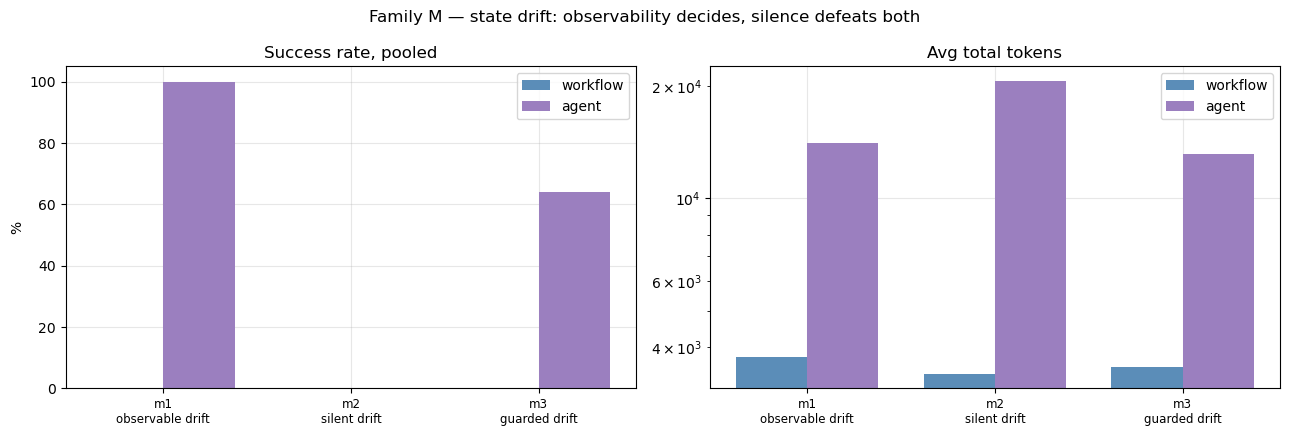

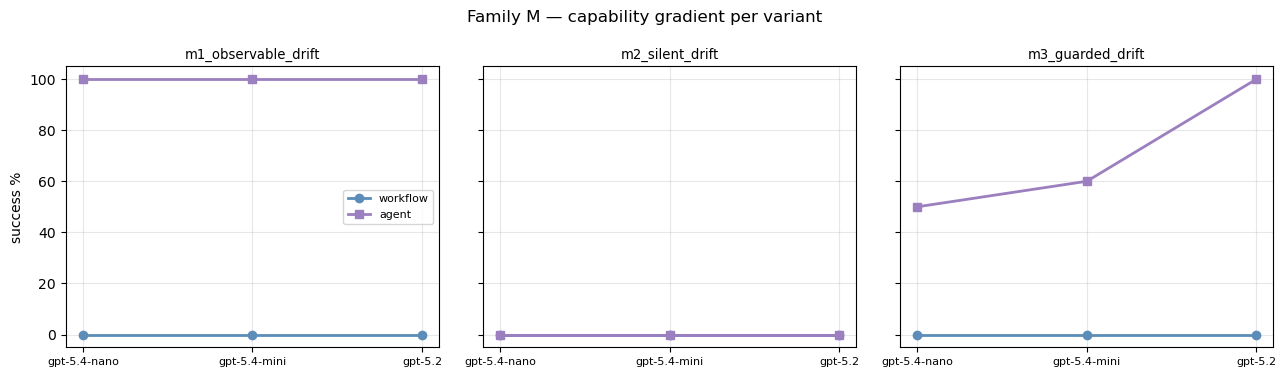

In [127]:
xs = np.arange(len(VARIANTS_M)); w = 0.38
labels = ['m1\nobservable drift', 'm2\nsilent drift', 'm3\nguarded drift']
f, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for i, p in enumerate(('workflow', 'agent')):
    off = (i - 0.5) * w
    ax[0].bar(xs + off, [_rate(fam_rows('M', variant=v, paradigm=p)) for v in VARIANTS_M], w, label=p, color=PCOL[p])
    ax[1].bar(xs + off, [max(_avg_tok(fam_rows('M', variant=v, paradigm=p)), 1) for v in VARIANTS_M], w, label=p, color=PCOL[p])
ax[0].set_title('Success rate, pooled'); ax[0].set_ylabel('%'); ax[0].set_ylim(0, 105)
ax[1].set_title('Avg total tokens'); ax[1].set_yscale('log')
for a in ax:
    a.set_xticks(xs); a.set_xticklabels(labels, fontsize=8.5); a.legend()
f.suptitle('Family M — state drift: observability decides, silence defeats both', fontsize=12)
plt.tight_layout(); plt.show()

f, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for a, v in zip(axes, VARIANTS_M):
    for p, marker in (('workflow', 'o'), ('agent', 's')):
        ys = []
        for m, ls in TIERS:
            sub = [r for r in fam_rows('M', variant=v, paradigm=p, model=m) if r['run_label'] in ls]
            ys.append(_rate(sub))
        a.plot(tx, ys, '-', marker=marker, color=PCOL[p], linewidth=2, label=p)
    a.set_title(v, fontsize=9.5); a.set_xticks(tx); a.set_xticklabels(tlabels, fontsize=8)
    a.set_ylim(-5, 105)
axes[0].set_ylabel('success %'); axes[0].legend(fontsize=8)
f.suptitle('Family M — capability gradient per variant', fontsize=12)
plt.tight_layout(); plt.show()

### Findings M

**m1 (observable drift): the cleanest paradigm separation in all of Phase 2b — after a diagnosis that is itself a finding.** Post-fix: workflow **0/25** vs agent **25/25, tier-invariant** (even nano is perfect). The workflow plans both closes and both notifications from pre-drift state and the executor sends the success mail for the externally-closed case; the agent sees "already closed" and applies the runbook branch. External state change with observable tool feedback behaves exactly like the G1 runtime-feedback mechanism — row 2.1's gate extends to environment dynamics (Liu & Li's *variability*, closing that gap). The pre-fix numbers (agent 4/25 with a capability inversion) were an artifact chain worth reporting: the agent legitimately emits **parallel tool calls in one turn**; LangGraph executes them concurrently; the tool's check-then-write shape (TOCTOU) let the stale close overwrite the drift sentinel. Fidelity fix: `attempt_close_case` is now atomic; the m1 drift is symmetric and race-free under any interleaving (IT-064).

**m2 (silent drift): the double zero.** Workflow 0/25 **and agent 0/25** — with no signal and no mandate, *neither* paradigm re-checks before writing; the agent's 20.6k tokens buy nothing. Silent drift is therefore **not a routing criterion**: it defeats the task regardless of paradigm and demands environment- and build-level answers (atomic/conditional writes, optimistic locking, freshness guards).

**m3 (guarded drift): the instructed guard rescues only the agent.** Agent 16/25 with a clean gradient (nano 5/10 → mini 6/10 → gpt-5.2 **5/5**); workflow **0/25 although it plans the mandated re-read** — the executor cannot branch on what the re-read returns. An instruction can activate a guard only in the paradigm whose control flow is runtime-resolved; capability determines how reliably (reference tier: perfect).

**Errors:** 9 hard errors, all mini workflow `ReadPlan` validation crashes on m1 — the same mini schema fragility as X-1 (identical runbook shape), now thrice-replicated.

**Method findings for 4.4:** capability inversions are review triggers (rule re-confirmed — the trace capture, not the summaries, settled it); tools facing agents must be atomic/idempotent because parallel tool-call emission amplifies every TOCTOU surface; environment simulations must be race-safe, not only payload- and query-faithful (completing the IT-062 lesson); the sentinel design let outcome-centric scoring distinguish drift-closes from run-closes without trajectories.

### Routing derivation — framework row 2.3 (resolved)

- **Observable drift → AGENT, hard break** (m1: W 0/25 vs A 25/25, tier-invariant): an environment change that surfaces through tool feedback is a runtime-feedback source — row 2.1's mechanism extended to external dynamics.
- **Instructed re-check guards are agent-only equipment** (m3: A 16/25, perfect at the reference tier; W 0/25 despite planning the re-read — it cannot branch). Below the reference tier the guard is unreliable → capability note.
- **Silent drift is excluded from routing** (m2: 0/50 combined): it is a *build mandate*, not a paradigm criterion — atomic/conditional writes, optimistic locking, freshness re-checks belong in every deployment regardless of the routing decision.
- Applied to the **TADF v1.1 table** below (row 2.3 leaves amber; changelog extended). With this, every Phase 2b family is analyzed; the remaining open items are row 6.2 (Phase 3 interviews) and payload behavior beyond the measured token range.

### Ergebnisse in einfacher Sprache (plain-language summary, Family M)

Familie M hat getestet: **Was passiert, wenn sich die Welt ändert, während die Aufgabe läuft** — ein Kollege schließt nebenbei einen Case, den du gerade bearbeiten sollst?

**Fall 1 — Die Änderung ist sichtbar (m1):** Das System meldet beim zweiten Schritt "ist schon geschlossen". **Ergebnis: Agent 25/25 auf jedem Modell, Workflow 0/25.** Der Agent liest die Meldung und lässt den Case in Ruhe; der Workflow hat seine Erfolgs-Mail schon vorher eingeplant und schickt sie trotzdem raus. Sichtbare Änderungen zur Laufzeit sind also derselbe harte Agent-Fall wie Laufzeit-Feedback (Zeile 2.1).

**Fall 2 — Die Änderung ist lautlos (m2):** Das Überschreiben gelingt ohne Warnung. **Ergebnis: beide 0/25.** Ohne Signal und ohne Auftrag prüft niemand nach — auch der Agent nicht. Das ist keine Paradigmen-Frage, sondern eine Bau-Pflicht: Schreiboperationen müssen selbst prüfen (atomare/bedingte Writes), egal welches Paradigma läuft.

**Fall 3 — Das Runbook verlangt "vor jeder Änderung nochmal nachschauen" (m3):** **Der Agent kann das ausführen** (mit starkem Modell 5/5), **der Workflow nicht** — er plant das Nachschauen sogar ein, kann aber auf das Ergebnis nicht reagieren (0/25). Eine Anweisung wirkt nur in dem Paradigma, das zur Laufzeit verzweigen kann.

**Und die Detektivgeschichte dahinter, die selbst ein Ergebnis ist:** Anfangs sah der Agent bei Fall 1 schlecht aus — aber die Trace-Analyse zeigte: Er machte alles richtig und schickte nur **beide Aktionen gleichzeitig** los (parallele Tool-Calls). Unser simuliertes Schließen-Tool prüfte erst und schrieb dann — in der Lücke dazwischen überholte der zweite Aufruf den Drift. Echte Systeme prüfen-und-schreiben in einem Schritt; das Tool tut das jetzt auch, und danach war der Agent perfekt. Merksatz: **Tools für Agents müssen gleichzeitige Aufrufe aushalten** — und auffällige Ergebnisse (ein starkes Modell schlechter als ein schwaches) immer erst diagnostizieren, dann interpretieren.

## 5. TADF v1.1 — framework state after Phase 2b

DSR discipline: the Phase 2a notebook (`results_analysis.ipynb`, Section 4.3) preserves the **v1** table exactly as it stood after the first analysis — including its amber placeholders. This section carries the **evolved artifact state (v1.1)** derived from the Phase 2b families, so the design trajectory stays inspectable phase by phase (design as a search process, Hevner G6).

**Changelog v1 → v1.1** (every change evidence-backed, IT references):

- **Row 1.2 calibrated** (family L, IT-060–062): measured input range replaces the placeholders — no success degradation up to ≈19k (workflow, single pass) / ≈41k (agent, accumulated) input tokens; volume is a cost lever; beyond the measured range explicitly untested.
- **Row 3.1 refined** (X-3, IT-059): the heterogeneity hard break applies to *unbounded per-item* variety; *bounded rule-generated* variety is capability-conditional (reference tier: workflow 5/5 at ~3× lower cost).
- **Row 3.2 order-confirmed** (X-1, IT-059): if the rules' input is a runtime outcome, row 2.1 has already fired — codifiability cannot rescue the plan (W 0/25 tier-invariant).
- **Row 3.3 resolved and split** (family P, IT-057): data-bounded count → workflow (25/25 both, 0.36× cost); outcome-dependent count → agent, hard break (W 0/25 tier-invariant).
- **Row 3.4 resolved** (P-c, IT-057): unknown source/tool → agent, hard break (24/25 vs 12/25; capability narrows the gap, never closes it).
- **Row 3.5 evidence note** (P-a/P-d): derived ordering and data-bounded counts stay plan-time decidable; P-d is capability-bound below the reference tier.
- **Representation decided** (family X, IT-059): the cascade remains the framework form; the static hierarchy (v2 candidate) is refuted — its D3 ⊐ D4 subordination holds only below the reference tier; **gate order is partially capability-dependent**, and Stage 3 carries the X-3 condition.
- **New build notes** (IT-061/062): parallel dispatch for bulk output (≥≈40 actions); emptiness check + bounded re-plan for workflow read stages over free-text search; placeholder guard before any executor.
- **Row 2.3 resolved** (family M, IT-063–065): observable state drift → agent, hard break (W 0/25 vs A 25/25, tier-invariant — external change is a runtime-feedback source); instructed re-check guards rescue only the agent (capability-bound, perfect at reference tier); *silent* drift defeats both paradigms (0/50) — a build mandate (atomic/conditional writes, optimistic locking, freshness guards), not a routing criterion.
- **New build note** (IT-064): tools facing agents must be atomic/idempotent — models emit parallel tool calls in one turn, and concurrency amplifies every check-then-act (TOCTOU) surface; environment simulations must be race-safe, not only payload- and query-faithful.
- **Row 1.2 reclassified** (consolidation decision): payload/context size moves out of the routing categories into **Next Steps (row 7.2, build calibration)** — family L showed volume has no routing consequence in the measured range (cost lever only); it tunes the build *after* the decision. The beyond-range amber moves with it.
- **Still open:** row 6.2 (Phase 3 interviews), payload behavior beyond the measured token range.


### TADF v1.1 — decision table (post-Phase-2b state)

The full evaluation as one **decision table**, grouped into seven categories in evaluation order — identical structure to the v1 table in the Phase 2a notebook, with the Phase-2b-derived changes applied (see changelog above). Read each question with its specification and take the decision in the answer columns: <span style="color:#c0392b;font-weight:bold">red = hard break</span> — routing is fixed, stop evaluating the routing categories; normal = the better choice or a recommendation *given the decisions taken so far*; <span style="color:#8a6d1a;font-style:italic">amber italic = first guideline with placeholders</span> — numbers and routing to be calibrated by the Phase 2b tests. Categories 4–7 are always evaluated, whatever was routed above. One gap is kept out of the table deliberately: a **hybrid** leaf (workflow with an embedded agentic resolution step) is suggested by the G failure census — the workflow's deficit there is a resolution *subtask*, not planning — but is untested; it enters via the Phase 4 case study, not via this table.

<table style="border-collapse:collapse;width:100%">
<tr><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">#</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Category</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Question</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Specification — when it applies</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">Yes &rarr;</th><th style="border:1px solid #cfd6db;padding:6px 8px;background:#dfe5e9;text-align:left;font-size:13px">No &rarr;</th></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">1.1</td><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">1 — Task Boundary<br>&amp; Requirements<br><span style="font-weight:normal;font-size:11px">(D5; decomposability)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the task fit into <b>one</b> execution?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">It does <i>not</i> fit if any of: &ge;6 simultaneous output constraints; one answer combining 3+ fields across systems; every item needs individual pre-resolution before acting. <i>Evidence: H-high 4%/0% &middot; B-high 32%/40% &middot; f-med-5 0/5 both.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">DECOMPOSE — hard break.</span> Split along the constraint / system / item axis, re-enter the table per subtask.</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.1</td><td rowspan="3" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">2 — Adaptability<br><span style="font-weight:normal;font-size:11px">(D1/D2; dynamic complexity)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does any step depend on a <b>runtime-observed result</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">The next action can only be chosen after seeing a tool result — including a single if&ndash;then branch on data that must first be read. <i>Evidence: F runtime W 0/15 vs A 13/15 (tier-invariant); f-med-2 1/5 vs 5/5.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Must retrieval build on its own <b>intermediate answers</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Query <i>n</i> can only be phrased once answer <i>n&minus;1</i> is known (multi-hop chains). <i>Evidence: A-high W 56% vs A 92%.</i> Exception: simple lookups <b>and</b> low error consequence &rarr; LLM-Workflow viable and cheaper (IT-012).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break</span> (unless the exception applies &rarr; LLM-Workflow).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">2.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Can the environment <b>state change mid-run</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">An external change that surfaces through tool feedback is a runtime-feedback source. <i>Evidence (Phase 2b, family M): observable drift W 0/25 vs A 25/25, tier-invariant; an instructed re-check guard rescues only the agent (16/25, perfect at the reference tier — the workflow plans the re-read but cannot branch, 0/25). SILENT drift defeats both paradigms (0/50) and is a build mandate, not a routing criterion.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break</span> (observable drift). Build, paradigm-independent: atomic/conditional writes, optimistic locking, freshness re-checks against silent drift.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.1</td><td rowspan="5" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">3 — Planability<br>of the Task<br><span style="font-weight:normal;font-size:11px">(D3/D4; coordinative complexity, codifiability; rows 3.3&ndash;3.4 resolved by Phase 2b family P)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the whole plan expressible as <b>one homogeneous structured object</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Fails when a bulk action carries heterogeneous per-item arguments (own values, owners, notes); identical bulk is fine regardless of count. <i>Evidence: f-med-3 W 2/5 vs A 5/5; f-med-4 5/5 both; validation crashes.</i> Refinement (Phase 2b, X-3): <b>bounded, rule-generated</b> variety is capability-conditional — at the reference tier the workflow carries it at 5/5 and ~3&times; cheaper, below it the agent wins; the hard break applies to <b>unbounded per-item</b> variety.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span></td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the task <b>fully plannable</b>, incl. decision logic as stable, fetchable rules?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Steps, tools and arguments known up front; rules complete and stable, retrievable at run time (policy handbook, thresholds, escalation matrix). <i>Evidence: D 100% @ 903&plusmn;4 tokens vs agent 80% @ 6&times;.</i> Order confirmed (Phase 2b, X-1): if the rules' <b>input</b> is a runtime outcome, row 2.1 has already fired — codifiability does not rescue the plan (W 0/25 vs A 24/25, tier-invariant).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-WORKFLOW + deterministic rule engine — better choice.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Steps and tools known, but the <b>number of calls</b> unknown?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Two evidence-backed sub-cases (Phase 2b family P): if the count is <b>data-bounded</b> — derivable from a read ("every matching record") — the two-stage form carries it. <i>Evidence (P-a): 25/25 for both paradigms, workflow at 0.36&times; tokens.</i> If the count depends on each action's <b>outcome</b> (repeat-until, e.g. process until the back-end refuses), the workflow is structurally blocked. <i>Evidence (P-b): W 0/25 across all tiers vs A 15/25.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Data-bounded &rarr; LLM-WORKFLOW (better choice). Outcome-dependent &rarr; <span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span> Build: iteration cap.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.4</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Number of calls known, but <b>which tool / step</b> unknown?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">The needed item lives in one of several tools/sources (mailbox vs calendar vs CRM) and the location is unknown at plan time. <i>Evidence (Phase 2b, P-c): agent 24/25 vs workflow 12/25; the workflow's read fan-out narrows the gap with capability (nano 3/10 &rarr; gpt-5.2 3/5) but never closes it.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#c0392b;font-weight:bold">AGENT — hard break.</span> Re-check at reference-tier capability, where the observed gap is small (n=5).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">3.5</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">None of the above fired?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Plannable task without special structure requirements. <i>Evidence: without a fired gate the 2.6&ndash;3.5&times; agent premium buys nothing (D, H); single-pass tasks at ceiling (C): either paradigm. Derived ordering and data-bounded counts remain plan-time decidable (Phase 2b: P-a 25/25; P-d both paradigms 5/5 at the reference tier, capability-bound below).</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-WORKFLOW + deterministic middle layer — default.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">&mdash;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.1</td><td rowspan="4" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">4 — Errors, Auditability<br>&amp; Robustness<br><span style="font-weight:normal;font-size:11px">(always evaluate)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Must errors be near-zero and every decision <b>audit-ready</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Workflow + deterministic engine on a strong model is near error-free and per-node auditable (D: 100% @ 903&plusmn;4; zero ordering violations in G; fixed graph = replayable trace). Agent loops are harder to audit and their errors skew permissive (12/15 under-escalations in D).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Prefer LLM-Workflow wherever rows 1&ndash;3 allow; add a deterministic validation layer regardless of paradigm.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Keep routing; log traces anyway. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is <b>under-blocking</b> the dangerous error direction?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Error directions are paradigm-typed: agent compliance errors are permissive (under-escalation, 80% in the dangerous direction); workflow verification errors are strict 2:1 (false fails). <i>Evidence: D error census; E strict-bias census.</i></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Deterministic decision layer mandatory (rule engine / verdict engine); do not leave the final decision inside a loop.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Calibrate strictness; use dual scoring (judge + deterministic). continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the consumer require a <b>schema-guaranteed output</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Downstream systems consume typed objects. The workflow enforces the schema by construction (structured output at every node); the agent needs post-validation. <i>Evidence: C was routed on the structured-output guarantee, not on cost (0.8&times; inverted ratio).</i> Caveat: schema complexity has its own ceiling (row 3.1).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">LLM-Workflow at parity; if Agent was routed above, add deterministic schema post-validation.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">4.4</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is the incoming input <b>clean and well-formed</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Weakest criterion in this category — evaluate last. Surface noise (typos, jargon, casual phrasing) barely discriminates (IT-048: both paradigms largely robust). On messy structured input the agent was slightly more robust (B robustness A 15/15 vs W 13/15, IT-036); the workflow is more accurate on clean input.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">No action; keep routing. continue &darr;</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">First choice: add an input-normalization step regardless of paradigm; only at persistent parity let messiness tip toward Agent. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">5.1</td><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">5 — Cost &amp; Latency<br><span style="font-weight:normal;font-size:11px">(always evaluate; Pareto axis, Kapoor et al. 2024)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Is cost or latency a <b>binding constraint</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A well-built workflow is 2.6&ndash;3.5&times; cheaper per run (up to 6&ndash;8&times; per solved task in B/D), difficulty-invariant in cost (B &asymp;2.1k flat; D 903&plusmn;4), and faster wherever the agent loops (B, F, G). The agent premium is justified <b>only</b> where a red gate fired above (A-high, F, G) — there it buys success, not comfort.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">At success parity choose LLM-Workflow; question every Agent decision that has no fired gate behind it.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decide on the remaining preferences. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">6.1</td><td rowspan="2" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">6 — Flexibility<br><span style="font-weight:normal;font-size:11px">(build-time trade-off)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Do you need to <b>start flexible</b> — input distribution not yet operationalizable?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A workflow binds you to an operationalized input distribution: one compiled graph then answers every same-type request (B 15/15) — but only within scope; out-of-scope inputs as the agent's fallback domain is <span style="color:#8a6d1a;font-style:italic">still unbacked (agenda 7)</span>. Building a workflow requires up front: output schemas, a deterministic middle layer, input operationalization. Agents start flexible but need their guardrails from day one.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Start as guarded Agent, harden into a Workflow once the input distribution stabilizes (hybrid migration path).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Build the Workflow directly. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">6.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">How stable is the <b>task definition</b> itself?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">A workflow binds build effort to a stable task shape (one compiled graph then serves every same-type request, B 15/15); if the process definition changes frequently, rebuild cost recurs, while an agent absorbs definition changes via prompt/runbook. <span style="color:#8a6d1a;font-style:italic">Not testable in Phase 2b (longitudinal) — routed to the Phase 3 practitioner interviews as a maintainability/APS question.</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Stable &rarr; the workflow investment amortizes (build once, run cheap).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Volatile &rarr; guarded Agent or late-binding workflow parts; revisit after stabilization. continue &darr;</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.1</td><td rowspan="4" style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px;background:#e8ecef;font-weight:bold">7 — Next Steps<br><span style="font-weight:normal;font-size:11px">(model &amp; architecture build-up — teaser; details in the build-notes discussion below)</span></td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Does the target model clear the <b>capability floor</b> of the chosen configuration?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decomposed-judgment workflows bind only from mid tier (E-high sign flip); agent recovery and runbook argument-binding fail on small models (IT-047/051); retrieval tasks need the per-model memorization re-check (IT-039); two-run discipline (10.2% temp-0 flip rate).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Proceed to build.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Adjust, do not re-route: raise the model tier or simplify the structure, then re-check.</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.2</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Context sizing — are the expected <b>payloads within the measured range</b>?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Build calibration, not routing (reclassified from the former row 1.2; family L): payload volume did not degrade success in the measured range — workflow single-pass contexts of &asymp;3k&ndash;19k input tokens, agent accumulated contexts of &asymp;9k&ndash;41k (operationalized via 8&ndash;160 records / 10&ndash;200 Gmail-shaped mails); the agent pays 2.2&ndash;3.8&times; for identical success.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">No task splitting needed; tune batching/chunking (workflow) or compaction (agent) as <b>cost</b> levers; parallel dispatch for bulk output &ge;&asymp;40 actions (latency inversion).</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px"><span style="color:#8a6d1a;font-style:italic">Untested territory — re-measure before trusting the calibration; reshape the task only if measurements show degradation.</span></td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.3</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decided <b>LLM-Workflow</b> — what to build?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Lessons from the grid (teaser): externalized rules/specs; deterministic executor / verdict engine / compliance checks as validation bottlenecks; schema-complexity budget for plan objects; revision caps; chunking as context parameter; canonical-minimal graph, LLM confined to semantic roles.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px" colspan="2">&rarr; Workflow build checklist (to be detailed in the discussion text).</td></tr>

<tr><td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">7.4</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Decided <b>Agent</b> — what to build?</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px">Lessons from the grid (teaser): iteration/recursion caps; prohibited-action guards; token-budget alarms; retry budgets; context compaction; per-model memorization checks; deterministic post-state validation of outcomes.</td>
<td style="border:1px solid #cfd6db;padding:6px 8px;vertical-align:top;font-size:13px" colspan="2">&rarr; Agent build checklist (to be detailed in the discussion text).</td></tr>
</table>

<small><span style="color:#c0392b;font-weight:bold">red = hard break</span> (routing fixed) &middot; normal = better choice / recommendation given prior decisions &middot; <span style="color:#8a6d1a;font-style:italic">amber italic = first guideline / placeholder, calibrated by Phase 2b</span> &middot; categories 4&ndash;7 always evaluated. Same evidence base as Sections 4&ndash;4.2.</small>


## Phase 2b synthesis — all four families complete

- **From family P:** plan uncertainty splits into two control axes that stay workflow-compatible (data-bounded count; derived ordering, capability-bound) and two gates that route to the agent (outcome-dependent count — structural; unknown source — capability-graded but persistent). Rows 3.3/3.4 resolved.
- **From family X:** the cascade order G1 ⊐ G2 is confirmed (codifiability cannot rescue runtime-fed rules); chains and heterogeneity compound to the agent without saturating; the **static hierarchy (v2) is refuted** — the D3-vs-D4 order is capability-dependent, so Stage 3 carries a real routing decision. Rows 3.1/3.2 annotated.
- **From family L:** payload volume is a **cost lever, not a correctness gate** within the measured range (workflow ≈3k–19k input tokens single-pass, agent ≈9k–41k accumulated; agent premium 2.2–3.8× at identical success); bulk output makes the sequential executor the latency bottleneck. Row 1.2 calibrated; the quoted-query episode yielded the read-side recovery asymmetry and the query-semantics fidelity lesson.
- **From family M:** *observability decides*: observable drift → agent, hard break (0/25 vs 25/25, tier-invariant); instructed guards are agent-only equipment; silent drift defeats both paradigms and is a build mandate. Row 2.3 resolved; the parallel-tool-call TOCTOU episode adds the race-safety build note.
- **Method rules validated across the phase:** both-paradigm zeros and capability inversions are review triggers (three artifacts found and fixed: p-d-3 gold, quoted-query semantics, close-tool TOCTOU — each documented as deviation with re-sweeps); trace capture settles what summaries cannot; adversarial gold variants and import-time anchor assertions belong in every seeder.
- **TADF state:** v1 (frozen, Phase 2a notebook) → **v1.1** (Section 5 above): rows 1.2, 2.3, 3.1–3.5 evidence-updated, representation fixed as capability-annotated cascade. Remaining open: row 6.2 (Phase 3), payload beyond the measured range. Next: the four-condition router evaluation (Conditions 3 vs 4) and Phases 3/4.


### Knowledge contributions — belief before, evidence, corrected rule

What this phase (together with Phase 2a) actually *changed* about the state of knowledge — the antidote to hindsight bias. Each row: the prior belief (practitioner heuristic or published claim), the evidence that tested it, and the corrected, evidence-graded rule now in TADF v1.1. Feeds thesis Chapter 6.

| Prior belief (source) | Evidence | Corrected rule (v1.1) |
|---|---|---|
| "If you can draw the flowchart, use a workflow" (practitioner heuristic) | f-med-4: 16 flowchartable steps, 5/5 both — but f-med-2: ONE readable branch, W 1/5 vs A 5/5 | Flowchartability is too coarse; the binding property is *where the branch's input comes from* (rows 2.1/3.3) |
| Step Predictability as one dimension (a-priori taxonomy 4.2.4) | P-a: unknown-but-data-bounded count 25/25 both at 0.36× cost; P-d: derived ordering, both 5/5 at reference tier | Predictability splits into sub-mechanisms; unknown count/order per se are workflow-fine — only *outcome-dependence* routes (row 3.3 split) |
| Route by a difficulty scalar (Su et al. 2025 DAAO; Gao et al. 2025) | A: tokens non-monotone over tiers (med > high); D: 100% at every difficulty; E: flips on capability, not difficulty | Difficulty is not a routing scalar — structural gates route; pre-registered head-to-head in Condition 3 vs 4 |
| A static decision hierarchy is possible (v2 candidate, Section 4.1 of the 2a notebook) | X-3: at reference tier both 5/5 with W ~3× cheaper; below it A wins (mini 10/10 vs 4/10) | **Gate order is partially capability-dependent** — cascade + Stage 3 capability check, not a static tree |
| "Heterogeneous bulk actions break workflows" (G4, Phase 2a reading) | f-med-3 (unbounded per-item): W 2/5 vs A 5/5 — but X-3 (rule-generated, 3 shapes): W 5/5 at reference | The schema ceiling binds on *unbounded per-item* variety; bounded rule-generated variety is capability-conditional (row 3.1) |
| "Large inputs break the paradigms" (practitioner folklore) | L: W 86/90 vs A 90/90 up to ≈19k/41k input tokens; zero hard errors in 210 runs | Volume is a **cost lever, not a correctness gate** in the measured range (row 1.2, calibrated) |
| "Agents handle change" (agent folklore) | m1 observable drift: A 25/25 vs W 0/25 — but m2 silent drift: **0/50 combined** | Only *observable* change routes to the agent; silent drift defeats both and is a build mandate (row 2.3) |
| Failure is a rate (accuracy-centric evaluation) | D: 12/15 agent errors permissive (dangerous direction); E: workflow 35:17 strict; G: zero workflow ordering violations | Error *direction* and failure *classes* are paradigm-typed — a deployment criterion of its own (category 4) |
| "Agent flexibility is worth the premium" | Without a fired gate the 2.6–7× token premium bought nothing (D, H, L parity cells) | Workflow is the evidence-based default; the premium pays exactly where a gate fires |
| Simulated environments are faithful if payloads look real (IT-016 scope) | Quoted-query miss (IT-062); TOCTOU under parallel tool calls (IT-064) | Environments must be *contract*-faithful and *race-safe*, not only payload-realistic — methods rule for 4.4 |


## 6. TADF consolidated — the hand-off layer

Closing consolidation of Phase 2b: the framework in its **light form** (TADF-Core, five questions), with the full routing knowledge unchanged underneath (the v1.1 table, Section 5), plus the pieces the audit found still unwritten — the consolidated Stage-3 block, the two build checklists that rows 7.2/7.3 only teased, the positioning against the paradigm-defining literature, and the resolution of the last open evidence flag (G cost premium, IT-054).

### TADF-Core — the one-page routing layer

> **Zerlege, was nicht in eine Ausführung passt. Nimm den Workflow als Default. Nimm den Agent genau dann, wenn Laufzeit-Information den Prozess steuert oder ein Plan-Objekt die Argument-Vielfalt nicht trägt — und prüfe jede Grenze gegen die Modellstärke.**

| # | Question | If … | Evidence anchor |
|---|---|---|---|
| Q0 | Does the task fit into **one execution**? | no → **DECOMPOSE** along the constraint / system / item axis, re-enter per subtask | row 1.1 — H-high 4%/0%, B-high 32%/40%, f-med-5 0/5 both |
| Q1 | Does **runtime information steer the process** — action outcomes, observable state changes, mandated re-checks, or result-dependent search paths? | yes → **AGENT** | rows 2.1–2.3, 3.3b, 3.4 — F 0/15 vs 13/15 · m1 0/25 vs 25/25 · m3 0/25 vs 16/25 · A-high 56% vs 92% · P-b/P-c |
| Q2 | Can **one structured plan object** carry the argument variety? | unbounded per-item variety → **AGENT**; bounded rule-generated variety → workflow from the reference tier | row 3.1 — f-med-3 2/5 vs 5/5 · X-3 5/5 W at reference, agent below |
| Q3 | Otherwise → **WORKFLOW** (default): externalize the rules, put the mechanics in a deterministic middle layer | the 2.6–7× agent premium buys nothing without a fired gate | rows 3.2/3.5 — D 100% @ 903±4 · parity cells D/H/L |
| Q4 | Always: **capability floor** (Stage 3 below) and the **preference pass** (cost, error direction, output guarantee) | adjust or re-check — never re-route on preferences alone | rows 4.x–7.1 |

The knowledge base below this card is the v1.1 decision table (Section 5) — every question footnotes into it; nothing in Core exists without a table row behind it.

### Stage 3 consolidated — the capability check per tier

What exactly changes with the deployment tier (the evidence that made gate order *partially capability-dependent*):

| Tier | What holds | What breaks / shifts |
|---|---|---|
| **Reference (gpt-5.2-class)** | All v1.1 rules as stated. Bounded rule-generated heterogeneity → workflow (X-3: 5/5 at ~3× lower cost). Derived ordering plan-time fine (P-d 5/5 both). Guarded adaptation reliable for the agent (m3 5/5). | — |
| **Mid (mini-class)** | Decomposed-judgment workflows bind (E-high 9/10). Agent guards mostly work (m3 6/10). | Bounded heterogeneity flips to the agent (X-3: 10/10 vs 4/10). Runbook-shaped instructions repeatedly crash the workflow's `ReadPlan`/`ActionPlan` schemas (15 crashes across X-1/m1) — schema-complexity budget is binding. |
| **Small (nano-class)** | Simple gates unchanged (F runtime, D rules, P-a). | Agent recovery and runbook argument-binding floors (IT-047/051); guarded adaptation unreliable (m3 5/10); structured-output crashes in both stages. Treat as stress/dev tier, not as a production routing basis. |

**Operating rule:** a routing decision made at one tier is re-validated when the deployment tier changes (the X-3/m3/P-d/E cells are exactly the ones that flip); single-run readings stay bounded by the 10.2% temperature-0 flip rate — two-run discipline.

### Build checklists — rows 7.3/7.4, now written out

**Decided LLM-Workflow — build checklist (each item traces to evidence):**
1. Deterministic middle layer (query executor / rule engine / verdict engine / compliance checks) — it carries the success *and* the cost invariance (D 903±4; B flat ~2.1k).
2. Rules and policies externalized; the LLM only extracts case facts (D: 12/15 agent errors were permissive re-derivations).
3. Schema-complexity budget for plan objects — bounded rule-generated variety only; unbounded per-item variety is not plannable (f-med-3; 15 mini ReadPlan/ActionPlan crashes).
4. Emptiness check + bounded re-plan for free-text reads (IT-062: query miss is unrecoverable in the two-stage form).
5. Placeholder guard before any executor — no "[DATE]"-style token may reach a real action (IT-062 trace).
6. Parallel dispatch for bulk output ≥ ~40 actions (L: sequential executor became the latency bottleneck, 15.7s vs 10.8s).
7. Chunking/batching as context parameters, not paradigm properties (C, IT-044; context sizing row 7.2).
8. Hard revision caps where feedback rounds exist (H decay 90→47→8→0%).
9. Operationalized input distribution documented — out-of-scope inputs are untested territory (deferred agenda 7).

**Decided Agent — build checklist:**
1. Iteration/recursion caps (b-high-4 overflow, the agent's crash mode).
2. Prohibited-action guards, explicit (IT-047: workflows *and* loops execute forbidden recovery steps when unguarded).
3. Token-budget alarms — loop context re-entry scales cost 2.2–7× (B 32k, F 26k, P-d 30k, L ×20 41k).
4. **Atomic/idempotent tools** — models emit parallel tool calls in one turn; every check-then-act surface races (IT-064).
5. Deterministic post-state validation / dual scoring — self-reports are unreliable (IT-052, P-b mini, m1 summaries).
6. Per-model memorization check for retrieval tasks (IT-031/039).
7. Context compaction for large payloads (L: the premium is pure re-entry).
8. Retry budgets on heterogeneous enumerations (F-med ~26k tokens observed).
9. Revision-turn cap for drafting loops (H).

**Paradigm-independent (always):** silent-drift protection at the data layer (conditional writes / optimistic locking — m2 defeated *both* paradigms 0/50); race-safe, contract-faithful environments and tools (IT-062/064); monitoring keyed to the paradigm's error *direction* (agent: permissive drift; workflow verification: strict bias).

### Positioning — what TADF adds beyond the paradigm-defining literature

- **vs. ReAct (Yao et al., 2023).** ReAct established *how* to interleave reasoning and acting and that the loop beats act-only/reason-only baselines; its premise ("adjust the plan according to the situation") is the ancestor of our Q1. TADF supplies what ReAct never tested: the **workflow counterfactual** (compiled graphs with deterministic layers — which match or beat the loop on the majority of the enterprise task space at 0.14–0.4× cost) and the **boundary conditions of the synergy claim**: the loop confers no adaptivity without observability (m2: 0/25), and interleaved self-revision can *hurt* (H decay). TADF is the empirical *when-and-at-what-price* to ReAct's *how*.
- **vs. the practitioner heuristic (Schluntz & Zhang, 2024).** "Flowchartable → workflow" is directionally right and too coarse: one readable branch breaks the workflow (f-med-2) while 16 flowchart steps do not (f-med-4). TADF replaces the proverb with falsifiable, evidence-graded rules incl. costs, error directions and capability conditions.
- **vs. difficulty-scalar routing (Su et al. 2025 DAAO; Gao et al. 2025).** Signal-level challenge, pre-registered for Condition 3 vs 4: difficulty is neither monotone in cost (A) nor predictive where structure decides (D, F-low). Constructive synthesis remains open: gates for the paradigm decision, a difficulty/capability signal for model-tier selection (their LLM-router idea ↔ our Stage 3).
- **vs. process-level scaling frameworks (Kim et al., 2026).** They coordinate multi-agent systems over decomposable processes and *presuppose* the task-level routing logic; TADF supplies exactly that layer (|A| = 1, per-task), adopting their validation-bottleneck mechanism and returning the decomposability evidence (three axes) at task granularity.

### Resolving the last open evidence flag — the G cost premium (IT-054)

*What the next cell does:* it recomputes the archetype-G token premium per tier under three definitions — per run, per *solved* run, and cost-per-success (total spend ÷ successes) — from the Phase 2a master CSV, settling the contradiction between the grid reading (rising premium) and the earlier "falling premium" claim.

In [128]:
import csv as _csv3, statistics as _st
_g = [r for r in _csv3.DictReader(open(REPO / 'data/results/final/master_results.csv'))
      if r['archetype'] == 'G' and r['kind'] == 'clean']
print(f'{"tier":6} {"paradigm":9} {"n":>3} {"solved":>6} {"tok/run":>8} {"tok/solved":>10} {"cost/success":>13}')
_rat = {}
for t in ('low', 'med', 'high'):
    d = {}
    for p in ('workflow', 'agent'):
        sub = [r for r in _g if r['difficulty'] == t and r['paradigm'] == p]
        ok = [r for r in sub if r['success'] == 'True']
        toks = [float(r['total_tokens']) for r in sub if r['total_tokens']]
        otoks = [float(r['total_tokens']) for r in ok if r['total_tokens']]
        d[p] = (_st.mean(toks), _st.mean(otoks) if otoks else None, sum(toks) / len(ok) if ok else None)
        print(f'{t:6} {p:9} {len(sub):>3} {len(ok):>6} {d[p][0]:>8.0f} {d[p][1] or 0:>10.0f} {d[p][2] or 0:>13.0f}')
    _rat[t] = tuple(d['agent'][i] / d['workflow'][i] for i in range(3))
print('\nagent/workflow premium:')
for t, (a, b, c) in _rat.items():
    print(f'  {t:5} per-run {a:.1f}x | per-solved {b:.1f}x | cost-per-success {c:.1f}x')

tier   paradigm    n solved  tok/run tok/solved  cost/success
low    workflow   25     16     3070       3072          4797
low    agent      25     22     6239       6221          7090
med    workflow   25     19     3621       3828          4765
med    agent      25     20    11006      10543         13758
high   workflow   25     11     4147       4402          9426
high   agent      25     14    14106       8161         25189

agent/workflow premium:
  low   per-run 2.0x | per-solved 2.0x | cost-per-success 1.5x
  med   per-run 3.0x | per-solved 2.8x | cost-per-success 2.9x
  high  per-run 3.4x | per-solved 1.9x | cost-per-success 2.7x


**Resolution (closes the IT-054 flag).** Both earlier readings were "true" under different definitions, and the difference is a **selection effect**: at the high tier the *successful* agent runs are the short, cheap ones (8.2k tokens) while the failed runs carry the expensive loops (pulling the per-run mean to 14.1k) — so the per-*solved* premium falls (2.0× → 2.8× → 1.9×) while the premium actually *paid* rises (per-run 2.0× → 3.4×; cost-per-success 1.5× → 2.7×). **For Section 4.5, quote per-run or cost-per-success; the per-solved comparison only with the survivor-bias caveat.** The earlier "3.9× → 1.4×" figure came from pre-rework sweeps and is superseded by these grid numbers.

### The TADF Reference Architecture

*What the next cell does:* it draws the **TADF Reference Architecture** in its final form (author's design, this consolidation). Four dashed knowledge domains — all assembled by the architect — surround the routing process: **Task Context** (per task), **Tool Landscape** and **System Architecture** (per environment; the former Enterprise-Knowledge domain, split into the tool-facing and the system-facing half), and **Deployment Context** (per deployment). The middle region **is** the framework: six dimensions (three *gates*, three *rankings*) embodying the v1.1 rules and thresholds, with the **Capability Check** as a cross-cutting element attached to dimensions 3–6 — exactly the steps the evidence showed to be capability-conditional (X-3, E-high, m3, P-d). The diamond carries the three outcomes: **Workflow / Agent / Decompose**.


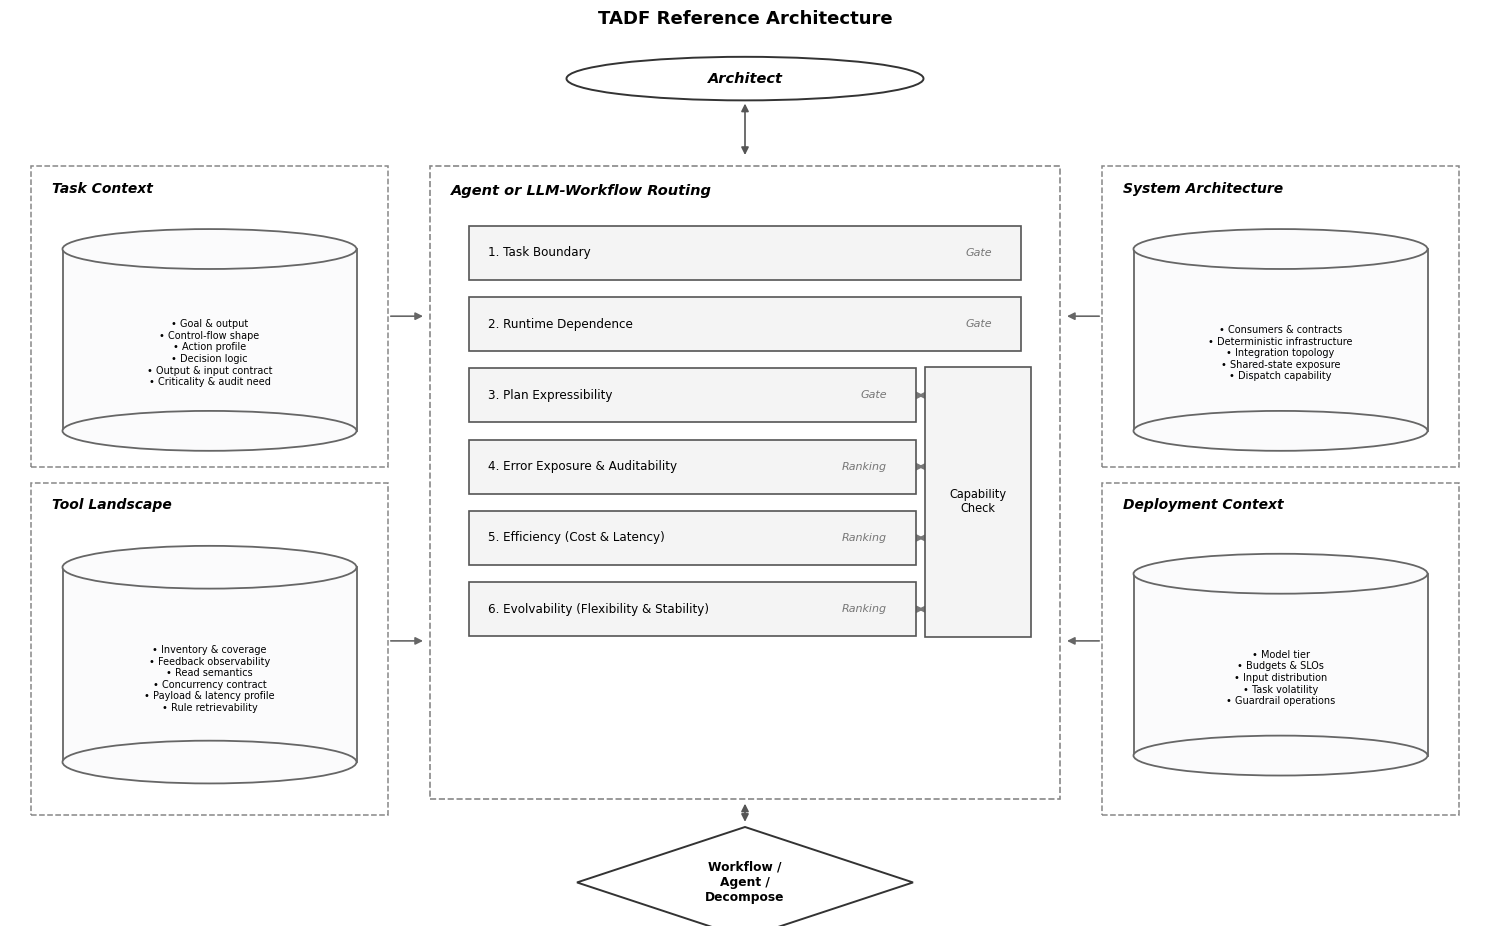

In [129]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Ellipse, Rectangle, Polygon

def _rbox(ax, x, y, w, h, fc='#f4f4f4', ec='#555'):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle='square,pad=0.3',
                                fc=fc, ec=ec, lw=1.2, zorder=3))

def _rcyl(ax, x, y, w, h, bullets, ec='#666', fs=7.0):
    eh = h * 0.18
    ax.add_patch(Rectangle((x - w/2, y - h/2 + eh/2), w, h - eh, fc='#fbfbfc', ec=ec, lw=1.3, zorder=2))
    ax.add_patch(Ellipse((x, y - h/2 + eh/2), w, eh, fc='#fbfbfc', ec=ec, lw=1.3, zorder=3))
    ax.add_patch(Ellipse((x, y + h/2 - eh/2), w, eh, fc='#fbfbfc', ec=ec, lw=1.3, zorder=4))
    ax.text(x, y - eh/3, bullets, ha='center', va='center', fontsize=fs, zorder=5)

def _rarr(ax, x1, y1, x2, y2, both=False, col='#666'):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='<|-|>' if both else '-|>',
                                 mutation_scale=11, color=col, lw=1.2, zorder=2))

f, ax = plt.subplots(figsize=(15, 9.5))
ax.set_xlim(0, 140); ax.set_ylim(0, 112); ax.axis('off')

# architect
ax.add_patch(Ellipse((70, 107), 34, 5.5, fc='#ffffff', ec='#333', lw=1.4, zorder=3))
ax.text(70, 107, 'Architect', ha='center', va='center', fontsize=10.5, fontweight='bold', fontstyle='italic', zorder=4)
_rarr(ax, 70, 104.2, 70, 97.0, both=True, col='#555')

# middle region: the framework process
ax.add_patch(Rectangle((40, 16), 60, 80, fc='none', ec='#888', lw=1.2, linestyle='--', zorder=1))
ax.text(42, 92.3, 'Agent or LLM-Workflow Routing', fontsize=10.5, fontweight='bold', fontstyle='italic')

DIMS = [('1. Task Boundary', 'Gate', 85.0, 52, 70, 93.5),
        ('2. Runtime Dependence', 'Gate', 76.0, 52, 70, 93.5),
        ('3. Plan Expressibility', 'Gate', 67.0, 42, 65, 83.5),
        ('4. Error Exposure & Auditability', 'Ranking', 58.0, 42, 65, 83.5),
        ('5. Efficiency (Cost & Latency)', 'Ranking', 49.0, 42, 65, 83.5),
        ('6. Evolvability (Flexibility & Stability)', 'Ranking', 40.0, 42, 65, 83.5)]
for label, tag, y, w, xc, xtag in DIMS:
    _rbox(ax, xc, y, w, 6.2)
    ax.text(xc - w/2 + 1.5, y, label, fontsize=8.6, va='center', ha='left', zorder=5)
    ax.text(xtag, y, tag, fontsize=8.0, va='center', ha='right', color='#777', fontstyle='italic', zorder=5)

# capability check (cross-cutting, attached to dims 3-6)
_rbox(ax, 92.2, 53.5, 9.5, 33.5)
ax.text(92.2, 53.5, 'Capability\nCheck', fontsize=8.2, ha='center', va='center', zorder=5, rotation=0)
for y in (67.0, 58.0, 49.0, 40.0):
    _rarr(ax, 86.2, y, 87.3, y, both=True, col='#777')

# diamond: the three outcomes
dia = Polygon([(70, 12.5), (86, 5.5), (70, -1.5), (54, 5.5)], closed=True, fc='#ffffff', ec='#333', lw=1.4, zorder=3)
ax.add_patch(dia)
ax.text(70, 5.5, 'Workflow /\nAgent /\nDecompose', ha='center', va='center', fontsize=8.8, fontweight='bold', zorder=4)
_rarr(ax, 70, 15.8, 70, 12.8, both=True, col='#555')

# corner knowledge domains
ax.add_patch(Rectangle((2, 58), 34, 38, fc='none', ec='#888', lw=1.1, linestyle='--', zorder=1))
ax.text(4, 92.6, 'Task Context', fontsize=10, fontweight='bold', fontstyle='italic')
_rcyl(ax, 19, 74, 28, 28,
      '\u2022 Goal & output\n\u2022 Control-flow shape\n\u2022 Action profile\n\u2022 Decision logic\n'
      '\u2022 Output & input contract\n\u2022 Criticality & audit need')

ax.add_patch(Rectangle((2, 14), 34, 42, fc='none', ec='#888', lw=1.1, linestyle='--', zorder=1))
ax.text(4, 52.6, 'Tool Landscape', fontsize=10, fontweight='bold', fontstyle='italic')
_rcyl(ax, 19, 33, 28, 30,
      '\u2022 Inventory & coverage\n\u2022 Feedback observability\n\u2022 Read semantics\n'
      '\u2022 Concurrency contract\n\u2022 Payload & latency profile\n\u2022 Rule retrievability')

ax.add_patch(Rectangle((104, 58), 34, 38, fc='none', ec='#888', lw=1.1, linestyle='--', zorder=1))
ax.text(106, 92.6, 'System Architecture', fontsize=10, fontweight='bold', fontstyle='italic')
_rcyl(ax, 121, 74, 28, 28,
      '\u2022 Consumers & contracts\n\u2022 Deterministic infrastructure\n\u2022 Integration topology\n'
      '\u2022 Shared-state exposure\n\u2022 Dispatch capability')

ax.add_patch(Rectangle((104, 14), 34, 42, fc='none', ec='#888', lw=1.1, linestyle='--', zorder=1))
ax.text(106, 52.6, 'Deployment Context', fontsize=10, fontweight='bold', fontstyle='italic')
_rcyl(ax, 121, 33, 28, 28,
      '\u2022 Model tier\n\u2022 Budgets & SLOs\n\u2022 Input distribution\n'
      '\u2022 Task volatility\n\u2022 Guardrail operations')

# domain -> process arrows
_rarr(ax, 36, 77, 39.6, 77)
_rarr(ax, 36, 36, 39.6, 36)
_rarr(ax, 104, 77, 100.4, 77)
_rarr(ax, 104, 36, 100.4, 36)

f.suptitle('TADF Reference Architecture', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the Reference Architecture (notation and evidence mapping).** *Dashed frame* = knowledge domain the **architect assembles**, partitioned by origin and change cadence (Task Context per task; Tool Landscape and System Architecture per environment; Deployment Context per deployment); *cylinder* = the domain's knowledge store; *solid box* = framework process step embodying the v1.1 rules and thresholds; *diamond* = the three routing outcomes; *arrow* = "feeds". The framework's own knowledge no longer appears as a store: its **routing knowledge is embodied in the six dimensions**, its **capability knowledge in the cross-cutting Capability Check** (attached to dimensions 3–6 — precisely the steps the evidence showed to be capability-conditional: X-3, E-high, m3, P-d), and its **build knowledge enters at the outcome** (checklists, guardrails, monitoring per the decision).

Evidence mapping of the domain items: **Task Context** — Goal & output (rows 1.1/4.3) · Control-flow shape (2.1: read-conditional branching, f-med-2) · Action profile (3.1: variety vs count) · Decision logic (3.2: codifiability) · Output & input contract (4.3 schema guarantee, 4.4 input quality) · Criticality & audit need (4.1/4.2). **Tool Landscape** — Inventory & coverage (3.4: unknown source, P-c) · Feedback observability (2.1/2.3: m1 vs m2) · Read semantics (IT-062: quoted-query contract) · Concurrency contract (IT-064: atomicity under parallel tool calls) · Payload & latency profile (5.1/7.2) · Rule retrievability (3.2: fetchable rules, D). **System Architecture** — Consumers & contracts (4.3: who consumes the output) · Deterministic infrastructure (can the environment host deterministic middle layers — the workflow advantage's carrier) · Integration topology (where the task sits in the larger pipeline; decompose re-entry) · Shared-state exposure (2.3: who else writes, drift) · Dispatch capability (parallel dispatch, the ≥≈40-actions latency inversion). **Deployment Context** — Model tier (Stage 3) · Budgets & SLOs (5.1) · Input distribution (6.1: operationalizability) · Task volatility (6.2, Phase 3) · Guardrail operations (can the org run the mandated guardrails/monitoring). *MECE*: the four domains are disjoint by origin (task / tools / system / deployment), jointly cover every input any dimension consumes, and the one thing the architect does not assemble — the framework's own knowledge — is exactly what the middle region and the Capability Check ship. Scope statement: that shipped knowledge is versioned per technology generation (GPT-5.x-era evidence).


### Interplay — how the three layers are used together

| Layer | What it is | When the architect uses it |
|---|---|---|
| **Application architecture** (above) | The knowledge map: which information must be gathered (pillars), which checks it feeds (chain), in which order | Once per environment/project: assemble the enterprise knowledge (tool landscape + deployment context) — and once per task: collect the task context (inputs & goal) |
| **TADF-Core** (Section 6 card) | The five-question routing pass | Per task, ~30 seconds: answers Q0–Q4 from the gathered knowledge; every answer footnotes into the table |
| **v1.1 decision table** (Section 5) | The reference with exact specifications, thresholds, evidence grades and hard/soft/amber status | Whenever a Core answer is ambiguous, a threshold is needed (≥6 constraints, ≥≈40 actions, measured token ranges), or the evidence grade matters (defense, review) |

Mapping architecture check → table rows: **1 Boundary → 1.1** (saturation signals, decomposition axes) · **2 Adaptability → 2.1–2.3** (mechanism tests, tier-invariant hard breaks) · **3 Planability → 3.1–3.5** (variety split, codifiability, capability conditions) · **4 Errors & Auditability → 4.1–4.4** (error directions, schema guarantee, input-quality tie-break) · **5 Cost & Latency → 5.1** (premium 2.6–7×, latency inversion) · **6 Flexibility → 6.1–6.2** (migration path; definition stability → Phase 3) · **7 Next Steps → 7.1–7.4** (Stage-3 floors, **context sizing** — reclassified here from the former row 1.2, since volume calibrates the *build*, not the *route* — and the two build checklists).

The division of labour is deliberate: the **architecture** prevents the classic failure of checking without knowing (running the Planability check without the tool landscape); the **Core** keeps the everyday decision light; the **table** carries the full routing knowledge with its evidence status — nothing in the upper layers exists without a row beneath it.


## Appendix (exploratory) — paradigm radar over the revised task dimensions

*Exploratory figure candidate for Section 4.5 — not (yet) a framework artifact and deliberately not part of the iteration log.* The radar shows how the two paradigms perform across the **revised, evidence-isolating dimensions**. Axis-selection rule, so the chart stays strictly data-based: each axis pools only the grid cells that *isolate* that dimension (crossed family-X cells are excluded; Phase 2a cells from `data/results/final/master_results.csv`, Phase 2b cells from the family results above). Left panel: pooled success rate. Right panel: token efficiency (cheaper paradigm = 1.0, the other scaled by cost ratio). Read with the usual caveats: per-axis n varies (25–270, printed below), the heterogeneity axis rests on a single instance family, and hard errors count as failures.

*What the next cell does:* it computes the eight axis values per paradigm from the raw results, prints the underlying table (axis, cells, n, success, avg tokens), and draws the two radar panels in the house palette.

axis                               paradigm     n  success  avg_tok
Runtime feedback                   workflow    65       0%     3875
Runtime feedback                   agent       65      82%    15586
Chained / unknown source           workflow    50      52%     5027
Chained / unknown source           agent       50      94%    10788
Unbounded heterogeneity            workflow     5      40%     4230
Unbounded heterogeneity            agent        5     100%    34596
Guarded adaptation                 workflow    25       0%     3522
Guarded adaptation                 agent       25      64%    13140
Codifiable rules                   workflow    75     100%      903
Codifiable rules                   agent       75      80%     5562
Plan-time control (count & order)  workflow    50      78%     3761
Plan-time control (count & order)  agent       50      84%    19558
Payload tolerance                  workflow    90      96%     6731
Payload tolerance                  agent       9

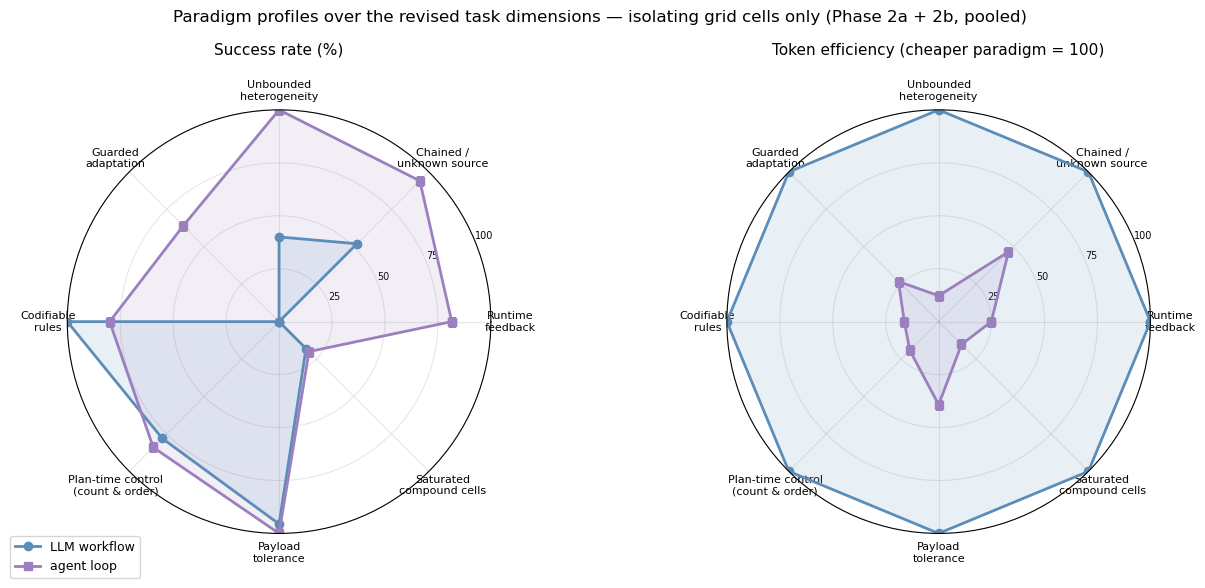

In [130]:
import csv as _csv

# ---- Phase 2a clean runs (master CSV) ----
_p2a = []
with (REPO / 'data/results/final/master_results.csv').open() as fh:
    for r in _csv.DictReader(fh):
        if r['kind'] != 'clean':
            continue
        _p2a.append({
            'archetype': r['archetype'], 'instance': r['instance'], 'difficulty': r['difficulty'],
            'paradigm': r['paradigm'],
            'ok': r['success'] == 'True',                      # errors/blank count as failure
            'tok': float(r['total_tokens']) if r['total_tokens'] else None,
        })

def _pool(sel2a, sel2b):
    """Pool Phase 2a rows (predicate) and Phase 2b cells [(family, variant), ...]."""
    out = {'workflow': [], 'agent': []}
    if sel2a:
        for r in _p2a:
            if sel2a(r):
                out[r['paradigm']].append((r['ok'], r['tok']))
    for fam, variant in sel2b:
        for p in out:
            for r in fam_rows(fam, variant=variant, paradigm=p):
                out[p].append((bool(r.get('correct')), float(r['total_tokens']) if r.get('total_tokens') else None))
    return out

AXES = [
    ('Runtime\nfeedback',            lambda r: r['instance'] in ('f-high-1', 'f-high-2', 'f-high-5'),
                                      [('P', 'b_count_outcome'), ('M', 'm1_observable_drift')]),
    ('Chained /\nunknown source',    lambda r: r['archetype'] == 'A' and r['difficulty'] == 'high',
                                      [('P', 'c_source_unknown')]),
    ('Unbounded\nheterogeneity',     lambda r: r['instance'] == 'f-med-3', []),
    ('Guarded\nadaptation',          None, [('M', 'm3_guarded_drift')]),
    ('Codifiable\nrules',            lambda r: r['archetype'] == 'D', []),
    ('Plan-time control\n(count & order)', None, [('P', 'a_count_read'), ('P', 'd_derived_order')]),
    ('Payload\ntolerance',           None, [('L', 'scan_scaling'), ('L', 'action_scaling'), ('L', 'mail_scaling')]),
    ('Saturated\ncompound cells',    lambda r: r['difficulty'] == 'high' and r['archetype'] in ('B', 'H'), []),
]

succ = {'workflow': [], 'agent': []}
eff = {'workflow': [], 'agent': []}
print(f'{"axis":34} {"paradigm":9} {"n":>4} {"success":>8} {"avg_tok":>8}')
for label, s2a, s2b in AXES:
    pool = _pool(s2a, s2b)
    toks = {}
    for p in ('workflow', 'agent'):
        runs = pool[p]
        rate = 100 * sum(1 for ok, _ in runs if ok) / len(runs) if runs else 0
        t = [tk for _, tk in runs if tk]
        toks[p] = statistics.mean(t) if t else 0
        succ[p].append(rate)
        print(f'{label.replace(chr(10), " "):34} {p:9} {len(runs):>4} {rate:>7.0f}% {toks[p]:>8.0f}')
    cheap = min(v for v in toks.values() if v) if any(toks.values()) else 1
    for p in ('workflow', 'agent'):
        eff[p].append(100 * cheap / toks[p] if toks[p] else 0)

# ---- radar ----
N = len(AXES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
labels = [a[0] for a in AXES]

f, axes_r = plt.subplots(1, 2, figsize=(13.5, 6), subplot_kw={'polar': True})
for ax, series, title in ((axes_r[0], succ, 'Success rate (%)'),
                          (axes_r[1], eff, 'Token efficiency (cheaper paradigm = 100)')):
    for p, marker in (('workflow', 'o'), ('agent', 's')):
        vals = series[p] + series[p][:1]
        ax.plot(angles, vals, marker=marker, linewidth=2, color=PCOL[p], label=('LLM workflow' if p == 'workflow' else 'agent loop'))
        ax.fill(angles, vals, color=PCOL[p], alpha=0.13)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 100); ax.set_yticks([25, 50, 75, 100]); ax.set_yticklabels(['25', '50', '75', '100'], fontsize=7)
    ax.set_title(title, fontsize=11, pad=18)
axes_r[0].legend(loc='lower left', bbox_to_anchor=(-0.15, -0.12), fontsize=9)
f.suptitle('Paradigm profiles over the revised task dimensions — isolating grid cells only (Phase 2a + 2b, pooled)', fontsize=12)
plt.tight_layout(); plt.show()

### Notes on the radar (exploratory)

- **The two shapes are near-complementary:** the agent's polygon covers the adaptivity half (runtime feedback, chained/unknown source, unbounded heterogeneity, guarded adaptation) where the workflow collapses to 0–52%; the workflow holds codifiable rules (100%) and stays at parity on the control axes (plan-time count/order, payload) — where the right panel shows it is the one earning the efficiency: token efficiency ≈100 on every axis, while the agent pays 2.6–7× premiums.
- **The saturation axis pulls both polygons inward** (≈18–20%) — the visual argument for *decompose* as the third routing outcome: no polygon covers that corner.
- **Honest limits:** the heterogeneity axis rests on one instance family (f-med-3, n=25); axes pool across capability tiers, so the capability-conditional effects (E-high, X-3, m3, P-d) are averaged into single points — a per-tier radar triptych (nano/mini/reference) would be the next iteration if this becomes a thesis figure; success and efficiency panels share axes but not scales semantics (rate vs ratio).
- If promoted to Section 4.5, the figure needs: per-axis n in the labels, the crossed-cell exclusion rule in the caption, and a pointer that the saturation axis is evidence for decomposition rather than for either paradigm.

## Appendix (exploratory) — phase metric overviews

*What the next cell does:* it draws one bar-panel row per phase — Phase 2a pooled over all archetype tasks (A–H, clean grid) and Phase 2b pooled over all family tasks (P/X/L/M, latest runs) — showing every measured metric side by side per paradigm: success rate, average total tokens, average latency, average tool calls, and hard-error counts. Same data discipline as everywhere: errors count as failures in the success bars and are shown separately as counts.

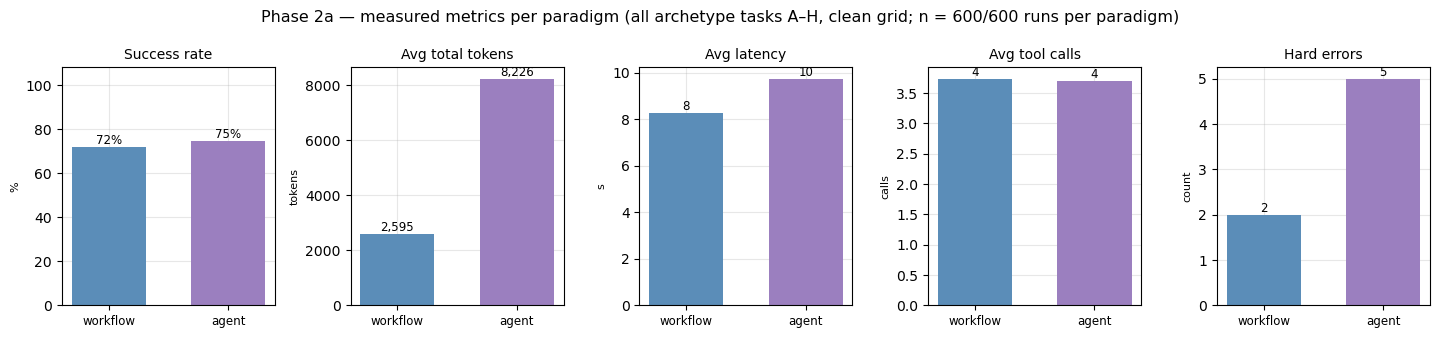

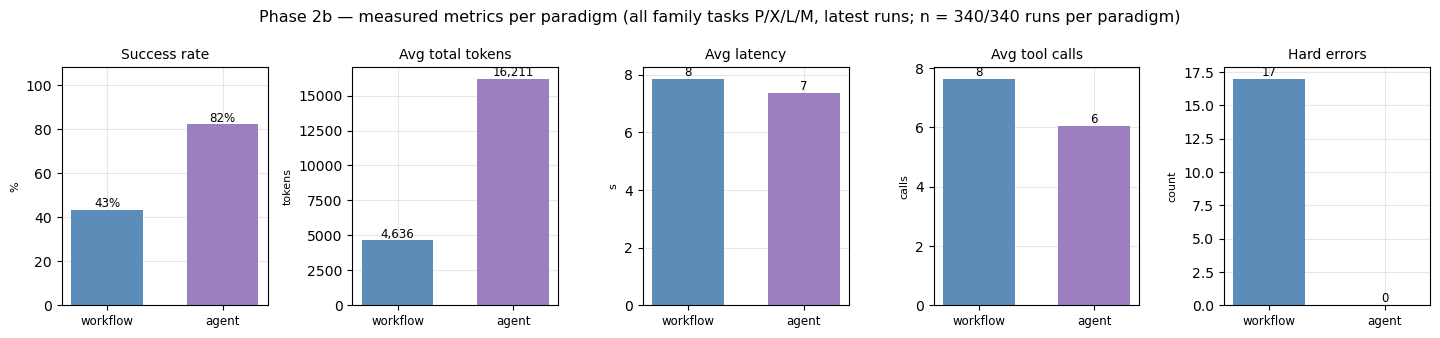

In [131]:
import csv as _csv2

def _metrics(runs):
    n = len(runs)
    ok = sum(1 for r in runs if r.get('ok'))
    toks = [r['tok'] for r in runs if r.get('tok')]
    lats = [r['lat'] for r in runs if r.get('lat')]
    tools = [r['tc'] for r in runs if r.get('tc') is not None]
    errs = sum(1 for r in runs if r.get('err'))
    return {'succ': 100 * ok / n if n else 0,
            'tok': statistics.mean(toks) if toks else 0,
            'lat': statistics.mean(lats) if lats else 0,
            'tc': statistics.mean(tools) if tools else 0,
            'err': errs, 'n': n}

# Phase 2a: clean grid runs from the master CSV
_a = {'workflow': [], 'agent': []}
with (REPO / 'data/results/final/master_results.csv').open() as fh:
    for r in _csv2.DictReader(fh):
        if r['kind'] != 'clean':
            continue
        _a[r['paradigm']].append({
            'ok': r['success'] == 'True',
            'tok': float(r['total_tokens']) if r['total_tokens'] else None,
            'lat': float(r['latency_s']) if r['latency_s'].strip() else None,
            'tc': float(r['tool_call_count']) if r['tool_call_count'].strip() else None,
            'err': bool((r['error'] or '').strip()) or r['iteration_overflow'] == 'True',
        })

# Phase 2b: all family rows (deduped latest runs, clean by construction)
_b = {'workflow': [], 'agent': []}
for r in ROWS:
    _b[r['paradigm']].append({
        'ok': bool(r.get('correct')),
        'tok': float(r['total_tokens']) if r.get('total_tokens') else None,
        'lat': float(r['latency_s']) if r.get('latency_s') else None,
        'tc': float(r['tool_call_count']) if r.get('tool_call_count') is not None else None,
        'err': bool(r.get('error')),
    })

PANELS = [('Success rate', 'succ', '%'), ('Avg total tokens', 'tok', 'tokens'),
          ('Avg latency', 'lat', 's'), ('Avg tool calls', 'tc', 'calls'),
          ('Hard errors', 'err', 'count')]

for phase, data, subtitle in (('Phase 2a', _a, 'all archetype tasks A–H, clean grid'),
                              ('Phase 2b', _b, 'all family tasks P/X/L/M, latest runs')):
    vals = {p: _metrics(data[p]) for p in ('workflow', 'agent')}
    f, axs = plt.subplots(1, 5, figsize=(14.5, 3.4))
    for ax, (title, key, unit) in zip(axs, PANELS):
        for i, p in enumerate(('workflow', 'agent')):
            ax.bar([i], [vals[p][key]], 0.62, color=PCOL[p], label=p if key == 'succ' else None)
            ax.text(i, vals[p][key], f'{vals[p][key]:,.0f}' if key != 'succ' else f'{vals[p][key]:.0f}%',
                    ha='center', va='bottom', fontsize=8.5)
        ax.set_title(title, fontsize=10); ax.set_ylabel(unit, fontsize=8)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['workflow', 'agent'], fontsize=8.5)
        if key == 'succ':
            ax.set_ylim(0, 108)
        ax.grid(axis='y', alpha=0.3)
    f.suptitle(f'{phase} — measured metrics per paradigm ({subtitle}; '
               f'n = {vals["workflow"]["n"]}/{vals["agent"]["n"]} runs per paradigm)', fontsize=11.5)
    plt.tight_layout(); plt.show()

### Notes on the metric overviews (exploratory)

- **The aggregate near-tie repeats in both phases** — success within a few points per phase — while tokens, latency, and tool calls stay far apart. This is the motivating non-result of the thesis made visible twice: the *aggregate* hides the per-task structure that the gates capture, in the confirmatory grid (2a) and in the isolating deep-dives (2b) alike.
- **Phase 2b's lower absolute success rates are by design**, not decay: the families deliberately concentrate on the hard, isolating cells (structural zeros like m2's 0/50 pull the pooled bars down), whereas 2a spans the full easy-to-hard archetype range. The two panels are therefore *not* comparable as "before/after" quality — only within-phase, between-paradigm.
- **The hard-error picture flips between phases:** Phase 2a was roughly symmetric (workflow schema crashes vs agent recursion overflows, 2 vs 5), but Phase 2b is one-sided — 17 workflow schema-validation crashes vs 0 agent errors. The families' runbook-style instructions repeatedly trigger the mini `ReadPlan`/`ActionPlan` fragility, while none of the family tasks pushed the agent into its overflow regime. Structural fragility is paradigm-typed AND task-shape-dependent — the 2a symmetry claim does not generalize unconditionally.